---
## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from matplotlib.patches import Patch
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import joblib
import shap

---
## Config

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────────
PATH_IP1 = "C:/Hackathon-GSK/data/processed/basetable_v5/ip1_basetable_v5.parquet"
PATH_IP3 = "C:/Hackathon-GSK/data/processed/basetable_v5/ip3_basetable_v5.parquet"

# ── Target ─────────────────────────────────────────────────────────────────────
TARGET = "GY_011 PSV - Global Yield total [%]"

# ── Columns derived from / directly related to the target (data leakage) ───────
LEAKY_COLS = [
    "clarif_Clarif - Yield Ag [%]",
    "clarif_007 Clarif - Yield total [%]",
    "UF_008 UF - Yield [%]",
    "PG_009 PG - Yield [%]",
    "PSV_010 PSV - Yield [%]",
    "GY_PSV - Global Yield [%]",
    "NF_PSV -% elimination prot.global [%]",
    "NF_PSV -% elimin. prot.global tot [%]",
    "NF_PSV-Purification factor global",
    "NF_DPV - Volume M199 [Liter]",
    "NF_PSV - pH",
    "NF_DPV - pH",
    "NF_DPV - Volume final [Liter]",
    "NF_029 DPV -Endotox gel clot meth [EU/ml]",
    "NF_Double check (pass/fail).3",
    "NF_Corrected Parameter.7",
    "NF_Corrected Parameter.8",
    "NF_Corrected Parameter.9",
    "NF_Corrected Parameter.10",
    "NF_3rd check corr. (pass/fail).3",
    #"Clarif 2 - Nr of train_missing_flag",
    # Rifqi Added post-prefixes below
    "UF_Clarif - % elimination prot. [%]",
    "UF_Clarif - % elimina. prot.tot [%]",
    "UF_Clarif - Ratio prot/Ag",
    "UF_Clarif - Purification factor",
    "UF_022 Clarif - pH",
    "PG_UF - % elimination prot. [%]",
    "PG_UF - % elimination prot tot [%]",
    "PG_UF - Ratio prot/Ag",
    "PG_UF - Purification factor",
    "DEAE_PG - % elimination prot. [%]",
    "DEAE_PG - % elimination prot tot [%]",
    "DEAE_PG - Ratio prot/Ag",
    "DEAE_PG - Purification factor",
    "GY_PSV - % elimination prot. [%]",
    "GY_PSV - Ratio prot/Ag",
    "GY_PSV - Purification factor",
]

# ── Metadata columns to always drop ────────────────────────────────────────────
META_COLS = [
    "Batch", "Material", "Plant", "Prodn Supervisor",
    "Reference Date", "Remark", "Remark.1", "Remark.2",
]

# ── Flag patterns — 'obs' catches (OBS), OBS_, _obs, (obs), any casing ─────────
FLAG_PATTERNS = ["pass/fail", "corrected parameter", "3rd check", "double check", "obs"]

# ── Columns to drop for modeling ────────────────────────────────────────────
COLS_TO_DROP = [
    "UF_Clarif - % elimination prot. [%]",
    "UF_Clarif - % elimina. prot.tot [%]",
    "UF_Clarif - Ratio prot/Ag",
    "UF_Clarif - Purification factor",
    "UF_022 Clarif - pH",
    "PG_UF - % elimination prot. [%]",
    "PG_UF - % elimination prot tot [%]",
    "PG_UF - Ratio prot/Ag",
    "PG_UF - Purification factor",
    "DEAE_PG - % elimination prot. [%]",
    "DEAE_PG - % elimination prot tot [%]",
    "DEAE_PG - Ratio prot/Ag",
    "DEAE_PG - Purification factor",
    "GY_PSV - % elimination prot. [%]",
    "GY_PSV - Ratio prot/Ag",
    "GY_PSV - Purification factor"
]

STAGE_TARGETS = {
    "clarif":     "clarif_007 Clarif - Yield total [%]",
    "uf":         "UF_008 UF - Yield [%]",
    "pg":         "PG_009 PG - Yield [%]",
    "psv_global": "PSV_010 PSV - Yield [%]",
}

---
## Shared Helper Functions


In [ ]:
# --- 1 ----------------------------------------------
def build_feature_dict(all_feature_list, serotype, abs_r_threshold, verbose=True):
    FEATURES = {}
    for stage, target in STAGE_TARGETS.items():
        mask = (
            (all_feature_list["Serotype"] == serotype) &
            (all_feature_list["Stage"]    == stage) &
            (all_feature_list["Abs_r"]    >= abs_r_threshold)
        )
        selected = all_feature_list[mask]["Feature"].tolist()
        FEATURES[stage] = {
            "target":   target,
            "features": selected,
        }
        if verbose:
            print(f"[{stage}] {len(selected)} features selected with Abs_r >= {abs_r_threshold}")
    return FEATURES


# --- 2 ----------------------------------------------
def feature_audit(df_ip1, df_ip3):
    ip1_cols = set(df_ip1.columns) - {"source"}
    ip3_cols = set(df_ip3.columns) - {"source"}


    print("=" * 50)
    print(f"  IP1 total features  : {len(ip1_cols)}")
    print(f"  IP3 total features  : {len(ip3_cols)}")


# --- 3 ----------------------------------------------
def run_stage_v3(stage_name, config, df, verbose=True):
    target   = config["target"]
    features = [f for f in config["features"] if f in df.columns]
    missing  = [f for f in config["features"] if f not in df.columns]
    if missing:
        print(f"  [WARN] features not found in df: {missing}")

    if verbose:
        print("=" * 75)
        print(f"STAGE: {stage_name.upper()}  |  target: {target}")
        print(f"Features: {len(features)}")
        print("=" * 75)

    # Drop rows where target is missing
    df_work = df[features + [target]].copy()
    df_work = df_work[df_work[target].notna()].reset_index(drop=True)
    X = df_work[features].values
    y = df_work[target].values

    if verbose:
        print(f"  n={len(df_work)} observations")

    loo = LeaveOneOut()

    # Define models
    models = {
        "OLS": LinearRegression(),
        "HGB": HistGradientBoostingRegressor(
            max_iter=100,
            max_depth=2, 
            learning_rate=0.05,
            min_samples_leaf=10, 
            l2_regularization=1.0,
            random_state=42
            ),
        "RandomForest": RandomForestRegressor(
            n_estimators=300, 
            max_depth=3, 
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=42
            ),
    }

    if verbose:
        print(f"\n  {'Model':<20} {'Train R²':>9} {'LOO R²':>8} {'Diff':>8} {'LOO RMSE':>10} {'NRMSE':>8} {'LOO MAE':>9}")
        print(f"  {'-'*80}")

    results = []
    for name, model in models.items():
        y_cv = cross_val_predict(model, X, y, cv=loo)
        model.fit(X, y)
        tr   = r2_score(y, model.predict(X))
        r2   = r2_score(y, y_cv)
        rmse = np.sqrt(mean_squared_error(y, y_cv))
        mae  = mean_absolute_error(y, y_cv)
        diff = tr - r2
        nrmse = rmse / y.mean()
        if verbose:
            print(f"  {name:<20} {tr:>9.4f} {r2:>8.4f} {diff:>8.4f} {rmse:>8.3f}pp {nrmse:>8.3f} {mae:>8.3f}pp")

        results.append({
            "model": name,
            "train_r2": tr,
            "loo_r2": r2,
            "diff": diff,
            "rmse": rmse,
            "nrmse": nrmse,
            "mae": mae,
            "num_features": len(features),
            "features": features, #this is a list
        })
    
    return results


# --- 4 ----------------------------------------------
def tune_threshold(stage_name, df, serotype, thresholds, all_feature_list, verbose=True):
    """
    Tunes the Pearson correlation threshold for a given stage and serotype.

    Args:
        stage_name:       e.g. "uf", "clarif", "pg", "psv"
        df:               the dataframe to use (e.g. df_ip1, df_ip3)
        serotype:         e.g. "IP1", "IP3"
        thresholds:       list of thresholds to test e.g. [0.01, 0.05, 0.1]
        all_feature_list: the full feature table

    Returns:
        best_features: dict of {model_name: [list of best features]}
    """
    tuning_results = []

    for thresh in thresholds:
        FEATURES = build_feature_dict(all_feature_list, serotype=serotype, abs_r_threshold=thresh)
        
        if stage_name not in FEATURES or len(FEATURES[stage_name]["features"]) == 0:
            print(f"  [SKIP] threshold={thresh} -> no features found for stage '{stage_name}'")
            continue

        results = run_stage_v3(stage_name, FEATURES[stage_name], df)

        for r in results:
            r["threshold"] = thresh
            tuning_results.append(r)

    # Convert to DataFrame
    tuning_df = pd.DataFrame(tuning_results)

    # Display full results
    if verbose:
        print()
        print("=" * 40)
        print(f"TUNING RESULTS — {stage_name.upper()} | {serotype}")
        print("=" * 40)
        display_cols = ["model", "threshold", "loo_r2", "diff", "num_features"]
        print(tuning_df[display_cols].sort_values(["model", "loo_r2"], ascending=[True, False]))

    # Display best per model
    print()
    print(f"BEST PER MODEL: ({stage_name})")
    best = tuning_df.loc[tuning_df.groupby("model")["loo_r2"].idxmax()]
    print(best[["model", "threshold", "loo_r2", "diff", "rmse", "num_features"]])

    # Extract best features per model
    best_features = {}
    for _, row in best.iterrows():
        best_features[row["model"]] = row["features"]
        if verbose:
            print(f"\n  Best features for {row['model']} (threshold={row['threshold']}):")
            for f in row["features"]:
                print(f"    - {f}")

    return best_features


# --- 5 ----------------------------------------------
def tune_hgb_optuna(stage_name, target, features, df, n_trials=100, diff_weight=0.5):
    
    df_work = df[features + [target]].copy()
    df_work = df_work[df_work[target].notna()].reset_index(drop=True)
    X = df_work[features].values
    y = df_work[target].values
    loo = LeaveOneOut()

    def objective(trial):
        params = {
            "max_iter":        trial.suggest_int("max_iter", 50, 500),
            "max_depth":       trial.suggest_int("max_depth", 2, 6),
            "learning_rate":   trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "min_samples_leaf":trial.suggest_int("min_samples_leaf", 5, 30),
            "l2_regularization": trial.suggest_float("l2_regularization", 0.1, 10.0, log=True),
            "max_features":    trial.suggest_float("max_features", 0.3, 1.0),
            "random_state":    42,
        }

        model  = HistGradientBoostingRegressor(**params)
        y_cv   = cross_val_predict(model, X, y, cv=loo)
        model.fit(X, y)
        loo_r2 = r2_score(y, y_cv)
        diff   = r2_score(y, model.predict(X)) - loo_r2

        return loo_r2 - diff_weight * diff

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    print(f"\n{'='*50}")
    print(f"OPTUNA HGB: {stage_name.upper()}")
    print(f"  Best score     : {study.best_value:.4f}")
    print(f"  Best params    : {study.best_params}")

    # Re-run with best params to get full metrics
    best_model = HistGradientBoostingRegressor(**study.best_params, random_state=42)
    y_cv       = cross_val_predict(best_model, X, y, cv=loo)
    best_model.fit(X, y)
    tr         = r2_score(y, best_model.predict(X))
    loo_r2     = r2_score(y, y_cv)
    diff       = tr - loo_r2
    rmse       = np.sqrt(mean_squared_error(y, y_cv))
    nrmse      = rmse / y.mean()
    mae        = mean_absolute_error(y, y_cv)

    print(f"  Train R²       : {tr:.4f}")
    print(f"  LOO R²         : {loo_r2:.4f}")
    print(f"  Diff           : {diff:.4f}")
    print(f"  RMSE           : {rmse:.4f}")
    print(f"  NRMSE          : {nrmse:.4f}")
    print(f"  MAE            : {mae:.4f}")

    return best_model, study


# --- 6 ----------------------------------------------
def tune_rf_optuna(stage_name, target, features, df, n_trials=50, diff_weight=0.5):
    
    df_work = df[features + [target]].copy()
    df_work = df_work[df_work[target].notna()].reset_index(drop=True)
    X = df_work[features].values
    y = df_work[target].values
    loo = LeaveOneOut()

    def objective(trial):
        params = {
            "n_estimators":     trial.suggest_int("n_estimators", 100, 500),
            "max_depth":        trial.suggest_int("max_depth", 2, 5),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 20),
            "min_samples_split":trial.suggest_int("min_samples_split", 2, 20),
            "max_features":     trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5]),
            "n_jobs":            -1,
            "random_state":     42,
        }

        model  = RandomForestRegressor(**params)
        y_cv   = cross_val_predict(model, X, y, cv=loo)
        model.fit(X, y)
        loo_r2 = r2_score(y, y_cv)
        diff   = r2_score(y, model.predict(X)) - loo_r2

        return loo_r2 - diff_weight * diff

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)

    print(f"\n{'='*50}")
    print(f"OPTUNA RF -> {stage_name.upper()}")
    print(f"  Best score     : {study.best_value:.4f}")
    print(f"  Best params    : {study.best_params}")

    # Re-run with best params to get full metrics
    best_model = RandomForestRegressor(**study.best_params, random_state=42)
    y_cv       = cross_val_predict(best_model, X, y, cv=loo, n_jobs=-1)
    best_model.fit(X, y)
    tr         = r2_score(y, best_model.predict(X))
    loo_r2     = r2_score(y, y_cv)
    diff       = tr - loo_r2
    rmse       = np.sqrt(mean_squared_error(y, y_cv))
    nrmse      = rmse / y.mean()
    mae        = mean_absolute_error(y, y_cv)

    print(f"  Train R²       : {tr:.4f}")
    print(f"  LOO R²         : {loo_r2:.4f}")
    print(f"  Diff           : {diff:.4f}")
    print(f"  RMSE           : {rmse:.4f}pp")
    print(f"  NRMSE          : {nrmse:.4f}")
    print(f"  MAE            : {mae:.4f}pp")

    return best_model, study

✓ Shared helper functions defined.


---
## Load Data

Basetables:

In [4]:
df_ip1 = pd.read_parquet(PATH_IP1)
df_ip3 = pd.read_parquet(PATH_IP3)

List of features with Pearson R:

In [5]:
all_feature_list = pd.read_csv("C:/Hackathon-GSK/Final_Submission/outputs/feature_selection/all_pearson_scores_local_v5.csv", encoding="latin-1")

all_feature_list_global = pd.read_csv("C:/Hackathon-GSK/Final_Submission/outputs/feature_selection/all_pearson_scores_global_v5.csv", encoding="latin-1")
all_feature_list_global=all_feature_list_global[~all_feature_list_global["Feature"].isin(COLS_TO_DROP)].reset_index(drop=True)
all_feature_list_global=all_feature_list_global[~all_feature_list_global["Feature"].isin(LEAKY_COLS)].reset_index(drop=True)
all_feature_list_global = all_feature_list_global[
    all_feature_list_global["Feature"] != "DEAE_DEAE - Stock duration pool PG"
]
all_feature_list_global["Stage"]="global"

---
### Feature Audit

Shows how many features each IP have

In [ ]:
feature_audit(df_ip1, df_ip3)

  IP1 total features  : 864
  IP3 total features  : 861


---
# Modeling

In [ ]:
all_feature_list=all_feature_list[~all_feature_list["Feature"].isin(COLS_TO_DROP)].reset_index(drop=True)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE SETS — dynamically built from teammate's feature selection table
# ─────────────────────────────────────────────────────────────────────────────

ABS_R_THRESHOLD = 0.1  # adjust this to test different model setups
SEROTYPE        = "IP1"  # change to "ip2" or "ip3" as needed

FEATURES = build_feature_dict(all_feature_list, SEROTYPE, ABS_R_THRESHOLD)

[clarif] 6 features selected with Abs_r >= 0.1
[uf] 2 features selected with Abs_r >= 0.1
[pg] 116 features selected with Abs_r >= 0.1
[psv_global] 4 features selected with Abs_r >= 0.1


## Hyperparameter tune threshold:

Finding the best threshold:

### Best features Clarif

In [ ]:
THRESHOLDS =[0.12, 0.125, 0.128, 0.15, 0.2]
best_features_clarif = tune_threshold("clarif", df_ip1, "IP1", THRESHOLDS, all_feature_list=all_feature_list)

[clarif] 5 features selected with Abs_r >= 0.12
[uf] 2 features selected with Abs_r >= 0.12
[pg] 92 features selected with Abs_r >= 0.12
[psv_global] 3 features selected with Abs_r >= 0.12
STAGE: CLARIF  |  target: clarif_007 Clarif - Yield total [%]
Features: 5
  n=88 observations

  Model                 Train R²   LOO R²     Diff   LOO RMSE    NRMSE   LOO MAE
  --------------------------------------------------------------------------------
  OLS                     0.1021  -0.0111   0.1132    6.886pp    0.101    5.301pp
  HGB                     0.3739  -0.0695   0.4434    7.082pp    0.104    5.535pp
  RandomForest            0.2388  -0.0184   0.2571    6.910pp    0.102    5.376pp
[clarif] 4 features selected with Abs_r >= 0.125
[uf] 2 features selected with Abs_r >= 0.125
[pg] 90 features selected with Abs_r >= 0.125
[psv_global] 3 features selected with Abs_r >= 0.125
STAGE: CLARIF  |  target: clarif_007 Clarif - Yield total [%]
Features: 4
  n=88 observations

  Model           

- Conclusion for clarif: OLS wins by a small margin, the LOO-CV R^2 is the highest but is not good at 0.025461, and the diff is the lowest at 0.056648, and the rmse is the lowest at 6.759992. So it is consistent in this metrics. number of features after threshold of 0.15: 2

#### Hyperparameter Tune Clarif

In [ ]:
best_hgb_clarif, study_hgb_clarif = tune_hgb_optuna(
    stage_name  = "clarif",
    target      = STAGE_TARGETS["clarif"],
    features    = best_features_clarif["HGB"],
    df          = df_ip1,
    n_trials    = 100,
    diff_weight = 0.5,
)


OPTUNA HGB: CLARIF
  Best score     : -0.0206
  Best params    : {'max_iter': 59, 'max_depth': 3, 'learning_rate': 0.010917564061610508, 'min_samples_leaf': 10, 'l2_regularization': 4.556969985976347, 'max_features': 0.3238332083262748}
  Train R²       : 0.1034
  LOO R²         : 0.0207
  Diff           : 0.0827
  RMSE           : 6.7764
  NRMSE          : 0.0995
  MAE            : 5.2933


In [143]:
best_rf_clarif, study_rf_clarif = tune_rf_optuna(
    stage_name  = "clarif",
    target      = STAGE_TARGETS["clarif"],
    features    = best_features_clarif["RandomForest"],
    df          = df_ip1,
    n_trials    = 50,
    diff_weight = 0.5,
)


OPTUNA RF -> CLARIF
  Best score     : -0.0196
  Best params    : {'n_estimators': 387, 'max_depth': 4, 'min_samples_leaf': 20, 'min_samples_split': 18, 'max_features': 'log2'}
  Train R²       : 0.0578
  LOO R²         : 0.0062
  Diff           : 0.0516
  RMSE           : 6.8264pp
  NRMSE          : 0.1003
  MAE            : 5.2959pp


Conclusion: OLS still wins:

#### STOP To check Clarif

In [198]:
# Best params found by Optuna are stored in study.best_params
final_ols_clarif = LinearRegression()

df_work = df_ip1[best_features_clarif["OLS"] + [STAGE_TARGETS["clarif"]]].copy()
df_work = df_work[df_work[STAGE_TARGETS["clarif"]].notna()].reset_index(drop=True)
X_final = df_work[best_features_clarif["OLS"]].values
y_final = df_work[STAGE_TARGETS["clarif"]].values

final_ols_clarif.fit(X_final, y_final)
print("Final model trained on all 88 observations ✓")

########################################################

loo    = LeaveOneOut()
y_cv   = cross_val_predict(final_ols_clarif, X_final, y_final, cv=loo)
tr     = r2_score(y_final, final_ols_clarif.predict(X_final))
loo_r2 = r2_score(y_final, y_cv)
diff   = tr - loo_r2
rmse   = np.sqrt(mean_squared_error(y_final, y_cv))
nrmse  = rmse / y_final.mean()
mae    = mean_absolute_error(y_final, y_cv)

print(f"\nTrain R²: {tr:.4f}")
print(f"LOO R²  : {loo_r2:.4f}")
print(f"Diff    : {diff:.4f}")
print(f"RMSE    : {rmse:.4f}pp")
print(f"NRMSE   : {nrmse:.4f}")
print(f"MAE     : {mae:.4f}pp")

########################################################

# Save model and feature list together so we know what columns to pass on Dashboard
joblib.dump({
    "model":    final_ols_clarif,
    "features": best_features_clarif["OLS"],
    "target":   STAGE_TARGETS["clarif"],
}, "C:/Hackathon-GSK/outputs/models/IP1_clarif_model.pkl")

print("\nModel saved to IP1_clarif_model.pkl ✓")

Final model trained on all 88 observations ✓

Train R²: 0.0821
LOO R²  : 0.0255
Diff    : 0.0566
RMSE    : 6.7600pp
NRMSE   : 0.0993
MAE     : 5.2629pp

Model saved to IP1_clarif_model.pkl ✓


#### SHAP Clarif

In [199]:
explainer_ols = shap.LinearExplainer(final_ols_clarif, X_final)
shap_values_ols = explainer_ols.shap_values(X_final)

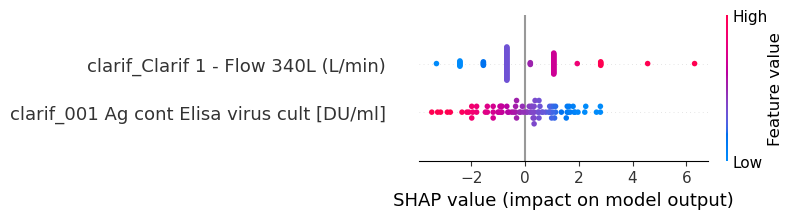

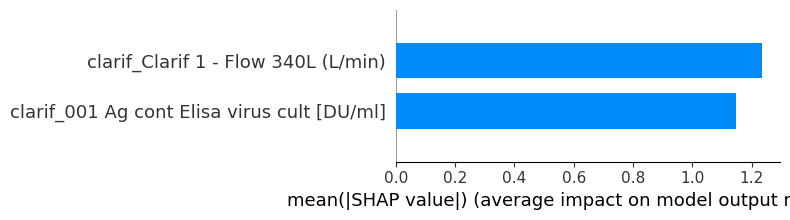

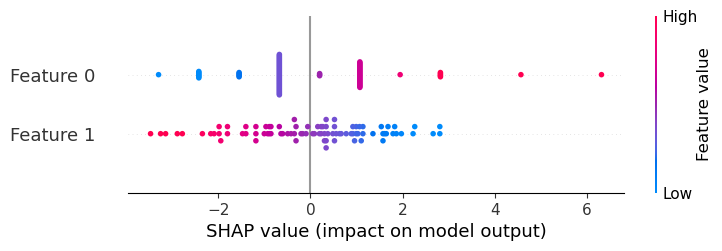

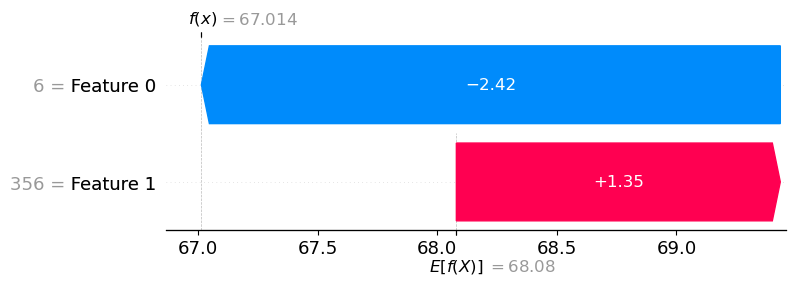

In [211]:
feature_names = best_features_clarif["OLS"]  # swap for the relevant feature list

# Summary plot: shows feature importance + direction of effect
shap.summary_plot(shap_values_ols, X_final, feature_names=feature_names)

# Bar plot: mean absolute SHAP value per feature (cleaner for reports)
shap.summary_plot(shap_values_ols, X_final, feature_names=feature_names, plot_type="bar")

# Single prediction explanation: useful for the dashboard
shap.waterfall_plot(explainer_ols(X_final)[0])  # explains first observation

### Best features UF

In [ ]:
THRESHOLDS = [0.003,0.005, 0.008, 0.03, 0.05, 0.09, 0.1, 0.15, 0.17, 0.199]
best_features_uf = tune_threshold("uf", df_ip1, "IP1", THRESHOLDS, all_feature_list=all_feature_list)

[clarif] 33 features selected with Abs_r >= 0.003
[uf] 6 features selected with Abs_r >= 0.003
[pg] 252 features selected with Abs_r >= 0.003
[psv_global] 8 features selected with Abs_r >= 0.003
STAGE: UF  |  target: UF_008 UF - Yield [%]
Features: 6
  n=88 observations

  Model                 Train R²   LOO R²     Diff   LOO RMSE    NRMSE   LOO MAE
  --------------------------------------------------------------------------------
  OLS                     0.0924  -0.0833   0.1757    9.844pp    0.107    7.597pp
  HGB                     0.5449   0.0301   0.5148    9.314pp    0.101    7.498pp
  RandomForest            0.3588   0.0592   0.2996    9.174pp    0.099    7.128pp
[clarif] 31 features selected with Abs_r >= 0.005
[uf] 6 features selected with Abs_r >= 0.005
[pg] 248 features selected with Abs_r >= 0.005
[psv_global] 8 features selected with Abs_r >= 0.005
STAGE: UF  |  target: UF_008 UF - Yield [%]
Features: 6
  n=88 observations

  Model                 Train R²   LOO R²     

- Conclusion of UF: UF is linear, since OLS wins, with a loo-cv of 0.722145, and an overfitting of 0.076858 (low), and RMSE is also the lowest by far at 4.985444.
This uses a threshold of 0.01 for absolute value of Pearson R on the features selected, leaving 10 features to the model. lets try adding engineered features next time.

In [145]:
best_hgb_uf, study_hgb_uf = tune_hgb_optuna(
    stage_name  = "uf",
    target      = STAGE_TARGETS["uf"],
    features    = best_features_uf["HGB"],
    df          = df_ip1,
    n_trials    = 100,
    diff_weight = 0.5,
)


OPTUNA HGB: UF
  Best score     : 0.0348
  Best params    : {'max_iter': 57, 'max_depth': 4, 'learning_rate': 0.03105881223790628, 'min_samples_leaf': 26, 'l2_regularization': 9.757730338166231, 'max_features': 0.5086739346422061}
  Train R²       : 0.1944
  LOO R²         : 0.0880
  Diff           : 0.1064
  RMSE           : 9.0323
  NRMSE          : 0.0978
  MAE            : 6.7840


In [146]:
best_rf_uf, study_rf_uf = tune_rf_optuna(
    stage_name  = "uf",
    target      = STAGE_TARGETS["uf"],
    features    = best_features_uf["RandomForest"],
    df          = df_ip1,
    n_trials    = 50,
    diff_weight = 0.5,
)


OPTUNA RF -> UF
  Best score     : 0.0416
  Best params    : {'n_estimators': 100, 'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 10, 'max_features': 'log2'}
  Train R²       : 0.2227
  LOO R²         : 0.1020
  Diff           : 0.1207
  RMSE           : 8.9627pp
  NRMSE          : 0.0971
  MAE            : 6.7948pp


CONCLUSION: Random Forest wins:

#### STOP To check UF

In [212]:
# Best params found by Optuna are stored in study.best_params
final_rf_uf = RandomForestRegressor(**{**study_rf_uf.best_params, "random_state": 42})

df_work = df_ip1[best_features_uf["RandomForest"] + [STAGE_TARGETS["uf"]]].copy()
df_work = df_work[df_work[STAGE_TARGETS["uf"]].notna()].reset_index(drop=True)
X_final = df_work[best_features_uf["RandomForest"]].values
y_final = df_work[STAGE_TARGETS["uf"]].values

final_rf_uf.fit(X_final, y_final)
print("Final model trained on all 88 observations ✓")

########################################################

loo    = LeaveOneOut()
y_cv   = cross_val_predict(final_rf_uf, X_final, y_final, cv=loo)
tr     = r2_score(y_final, final_rf_uf.predict(X_final))
loo_r2 = r2_score(y_final, y_cv)
diff   = tr - loo_r2
rmse   = np.sqrt(mean_squared_error(y_final, y_cv))
nrmse  = rmse / y_final.mean()
mae    = mean_absolute_error(y_final, y_cv)

print(f"\nTrain R²: {tr:.4f}")
print(f"LOO R²  : {loo_r2:.4f}")
print(f"Diff    : {diff:.4f}")
print(f"RMSE    : {rmse:.4f}pp")
print(f"NRMSE   : {nrmse:.4f}")
print(f"MAE     : {mae:.4f}pp")

########################################################

# Save model and feature list together so we know what columns to pass on Dashboard
joblib.dump({
    "model":    final_rf_uf,
    "features": best_features_uf["RandomForest"],
    "target":   STAGE_TARGETS["uf"],
}, "C:/Hackathon-GSK/outputs/models/IP1_uf_model.pkl")

print("\nModel saved to IP1_uf_model.pkl ✓")

Final model trained on all 88 observations ✓

Train R²: 0.2227
LOO R²  : 0.1020
Diff    : 0.1207
RMSE    : 8.9627pp
NRMSE   : 0.0971
MAE     : 6.7948pp

Model saved to IP1_uf_model.pkl ✓


#### SHAP UF

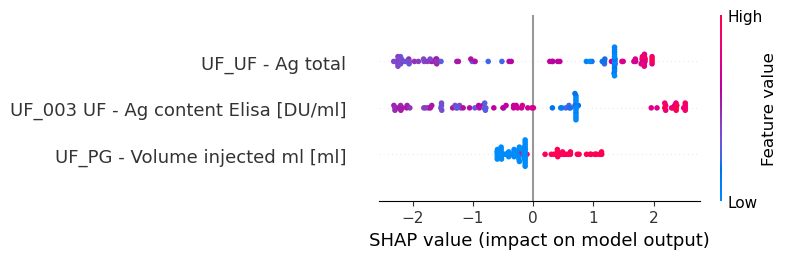

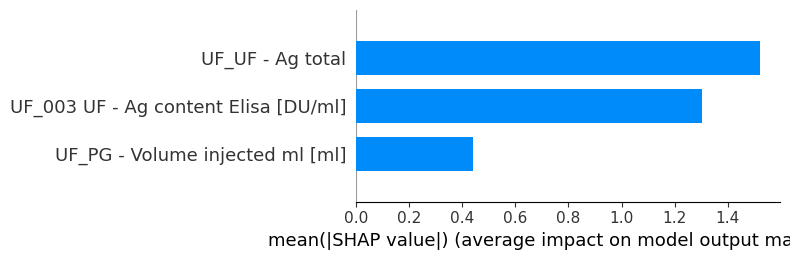

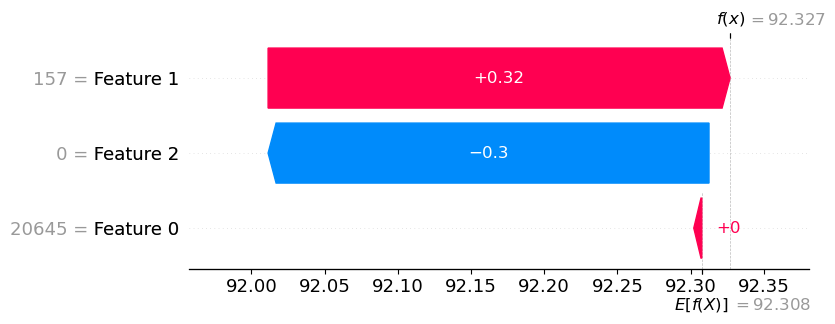

In [217]:
explainer_rf  = shap.TreeExplainer(final_rf_uf)
shap_values_rf = explainer_rf.shap_values(X_final)

feature_names = best_features_uf["RandomForest"]

# Summary plot: shows feature importance + direction of effect
shap.summary_plot(shap_values_rf, X_final, feature_names=feature_names)

# Bar plot: mean absolute SHAP value per feature (cleaner for reports)
shap.summary_plot(shap_values_rf, X_final, feature_names=feature_names, plot_type="bar")

# Single prediction explanation: useful for the dashboard
shap.waterfall_plot(explainer_rf(X_final)[0])  # explains first observation

### Best features PG

In [ ]:
THRESHOLDS = [0.042, 0.05, 0.19, 0.2, 0.2273, 0.29, 0.3, 0.315]
best_features_pg = tune_threshold("pg", df_ip1, "IP1", THRESHOLDS, all_feature_list=all_feature_list)

[clarif] 18 features selected with Abs_r >= 0.042
[uf] 5 features selected with Abs_r >= 0.042
[pg] 203 features selected with Abs_r >= 0.042
[psv_global] 5 features selected with Abs_r >= 0.042
STAGE: PG  |  target: PG_009 PG - Yield [%]
Features: 203
  n=88 observations

  Model                 Train R²   LOO R²     Diff   LOO RMSE    NRMSE   LOO MAE
  --------------------------------------------------------------------------------
  OLS                     1.0000 -6095.5172 6096.5172  461.410pp    5.571  177.585pp
  HGB                     0.7895   0.0003   0.7892    5.909pp    0.071    4.356pp
  RandomForest            0.4569   0.0474   0.4095    5.768pp    0.070    4.434pp
[clarif] 14 features selected with Abs_r >= 0.05
[uf] 4 features selected with Abs_r >= 0.05
[pg] 190 features selected with Abs_r >= 0.05
[psv_global] 5 features selected with Abs_r >= 0.05
STAGE: PG  |  target: PG_009 PG - Yield [%]
Features: 190
  n=88 observations

  Model                 Train R²   LOO R²  

- Conclusions for PG: Random Forest wins slightly with an LOO-CV R^2 of 0.157, and the lowest RMSE by a small margin of 5.423, the difference as well is the smallest, being 0.2295. Ideal number of features: 8 with a threshold of 0.3

In [148]:
best_hgb_pg, study_hgb_pg = tune_hgb_optuna(
    stage_name  = "pg",
    target      = STAGE_TARGETS["pg"],
    features    = best_features_pg["HGB"],
    df          = df_ip1,
    n_trials    = 100,
    diff_weight = 0.5,
)


OPTUNA HGB: PG
  Best score     : 0.0650
  Best params    : {'max_iter': 335, 'max_depth': 3, 'learning_rate': 0.010076177831851713, 'min_samples_leaf': 24, 'l2_regularization': 0.35876493800932274, 'max_features': 0.9150674836990592}
  Train R²       : 0.3999
  LOO R²         : 0.1767
  Diff           : 0.2232
  RMSE           : 5.3621
  NRMSE          : 0.0647
  MAE            : 4.1333


In [149]:
best_rf_pg, study_rf_pg = tune_rf_optuna(
    stage_name  = "pg",
    target      = STAGE_TARGETS["pg"],
    features    = best_features_pg["RandomForest"],
    df          = df_ip1,
    n_trials    = 50,
    diff_weight = 0.5,
)


OPTUNA RF -> PG
  Best score     : 0.0543
  Best params    : {'n_estimators': 159, 'max_depth': 4, 'min_samples_leaf': 12, 'min_samples_split': 2, 'max_features': 'sqrt'}
  Train R²       : 0.2562
  LOO R²         : 0.1216
  Diff           : 0.1346
  RMSE           : 5.5386pp
  NRMSE          : 0.0669
  MAE            : 4.2831pp


CONCLUSION: This one changed, now HGB wins!

#### STOP To check PG

In [218]:
# Best params found by Optuna are stored in study.best_params
final_hgb_pg = HistGradientBoostingRegressor(**{**study_hgb_pg.best_params, "random_state": 42})

df_work = df_ip1[best_features_pg["HGB"] + [STAGE_TARGETS["pg"]]].copy()
df_work = df_work[df_work[STAGE_TARGETS["pg"]].notna()].reset_index(drop=True)
X_final = df_work[best_features_pg["HGB"]].values
y_final = df_work[STAGE_TARGETS["pg"]].values

final_hgb_pg.fit(X_final, y_final)
print("Final model trained on all 88 observations ✓")

########################################################

loo    = LeaveOneOut()
y_cv   = cross_val_predict(final_hgb_pg, X_final, y_final, cv=loo)
tr     = r2_score(y_final, final_hgb_pg.predict(X_final))
loo_r2 = r2_score(y_final, y_cv)
diff   = tr - loo_r2
rmse   = np.sqrt(mean_squared_error(y_final, y_cv))
nrmse  = rmse / y_final.mean()
mae    = mean_absolute_error(y_final, y_cv)

print(f"\nTrain R²: {tr:.4f}")
print(f"LOO R²  : {loo_r2:.4f}")
print(f"Diff    : {diff:.4f}")
print(f"RMSE    : {rmse:.4f}pp")
print(f"NRMSE   : {nrmse:.4f}")
print(f"MAE     : {mae:.4f}pp")

########################################################

# Save model and feature list together so we know what columns to pass on Dashboard
joblib.dump({
    "model":    final_hgb_pg,
    "features": best_features_pg["HGB"],
    "target":   STAGE_TARGETS["pg"],
}, "C:/Hackathon-GSK/outputs/models/IP1_pg_model.pkl")

print("\nModel saved to IP1_pg_model.pkl ✓")

Final model trained on all 88 observations ✓

Train R²: 0.3999
LOO R²  : 0.1767
Diff    : 0.2232
RMSE    : 5.3621pp
NRMSE   : 0.0647
MAE     : 4.1333pp

Model saved to IP1_pg_model.pkl ✓


#### SHAP PG

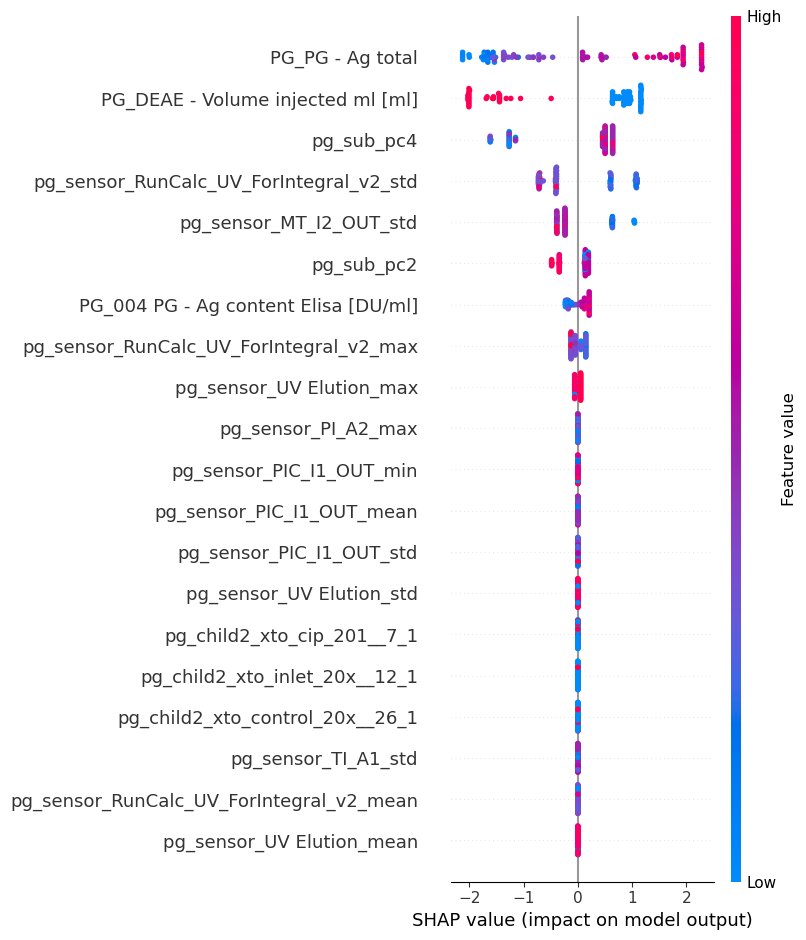

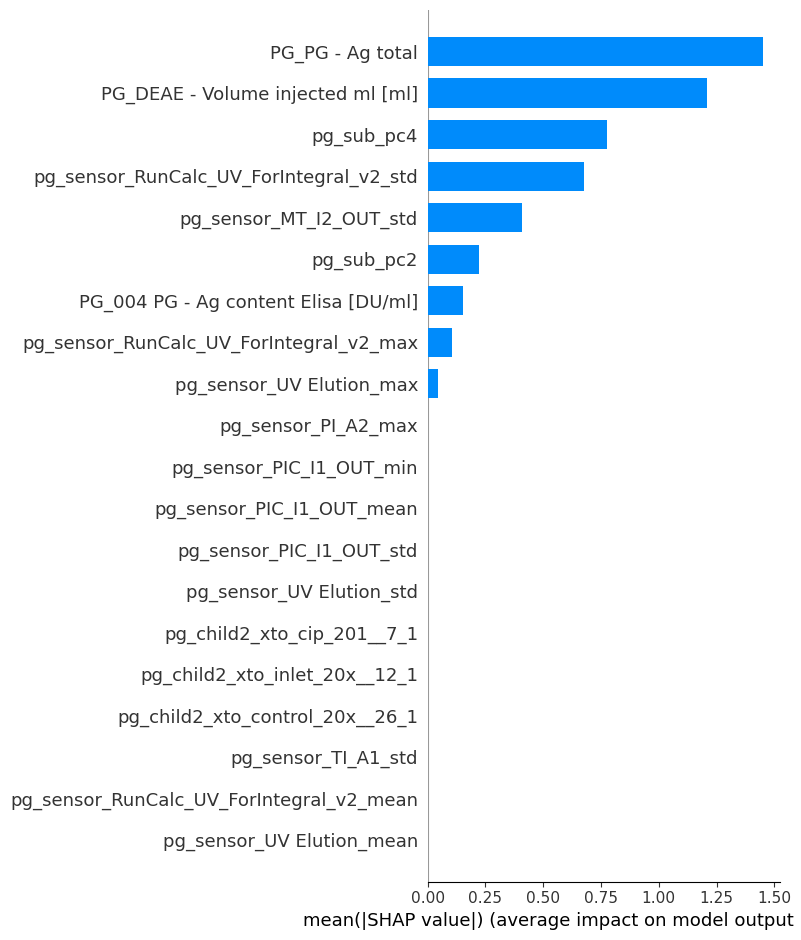

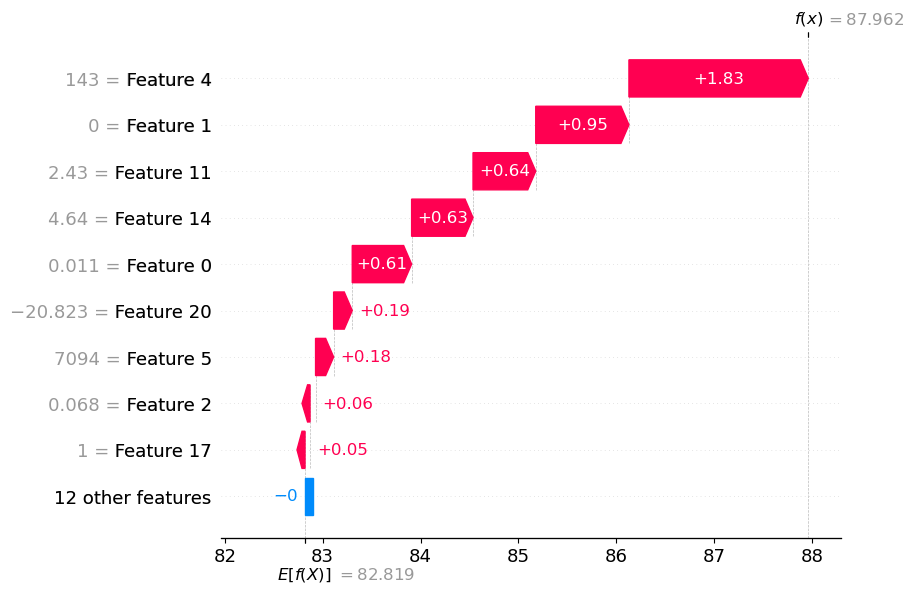

In [219]:
explainer_hgb_pg   = shap.TreeExplainer(final_hgb_pg)
shap_values_hgb_pg = explainer_hgb_pg.shap_values(X_final)

feature_names = best_features_pg["HGB"]

# Summary plot — shows feature importance + direction of effect
shap.summary_plot(shap_values_hgb_pg, X_final, feature_names=feature_names)

# Bar plot — mean absolute SHAP value per feature (cleaner for reports)
shap.summary_plot(shap_values_hgb_pg, X_final, feature_names=feature_names, plot_type="bar")

# Single prediction explanation — useful for the dashboard
shap.waterfall_plot(explainer_hgb_pg(X_final)[0])  # explains first observation

### Best features PSV

In [ ]:
THRESHOLDS = [0.001, 0.005, 0.01, 0.03, 0.05, 0.1, 0.15, 0.199]
best_features_psv = tune_threshold("psv_global", df_ip1, "IP1", THRESHOLDS, all_feature_list=all_feature_list)

[clarif] 33 features selected with Abs_r >= 0.001
[uf] 6 features selected with Abs_r >= 0.001
[pg] 252 features selected with Abs_r >= 0.001
[psv_global] 9 features selected with Abs_r >= 0.001
STAGE: PSV_GLOBAL  |  target: PSV_010 PSV - Yield [%]
Features: 9
  n=88 observations

  Model                 Train R²   LOO R²     Diff   LOO RMSE    NRMSE   LOO MAE
  --------------------------------------------------------------------------------
  OLS                     0.4640   0.3384   0.1255    5.660pp    0.082    4.394pp
  HGB                     0.7504   0.4066   0.3438    5.360pp    0.077    4.154pp
  RandomForest            0.5838   0.3484   0.2353    5.617pp    0.081    4.426pp
[clarif] 31 features selected with Abs_r >= 0.005
[uf] 6 features selected with Abs_r >= 0.005
[pg] 248 features selected with Abs_r >= 0.005
[psv_global] 8 features selected with Abs_r >= 0.005
STAGE: PSV_GLOBAL  |  target: PSV_010 PSV - Yield [%]
Features: 8
  n=88 observations

  Model                 Tr

- Conclusion for PSV: HGB wins with the highest LOO-CV R^2 of 0.625648, and while the difference is the highest being 0.246374, it does have the lowest RMSE by a significant margin, being 4.257728. THe optimal number of features is 11 after a threshold of 0.005

In [151]:
best_hgb_psv, study_hgb_psv = tune_hgb_optuna(
    stage_name  = "psv_global",
    target      = STAGE_TARGETS["psv_global"],
    features    = best_features_psv["HGB"],
    df          = df_ip1,
    n_trials    = 100,
    diff_weight = 0.5,
)


OPTUNA HGB: PSV_GLOBAL
  Best score     : 0.3401
  Best params    : {'max_iter': 289, 'max_depth': 6, 'learning_rate': 0.013900994567144526, 'min_samples_leaf': 15, 'l2_regularization': 1.5678944436722202, 'max_features': 0.966100219575329}
  Train R²       : 0.7301
  LOO R²         : 0.4701
  Diff           : 0.2600
  RMSE           : 5.0655
  NRMSE          : 0.0731
  MAE            : 3.8872


In [152]:
best_rf_psv, study_rf_psv = tune_rf_optuna(
    stage_name  = "psv_global",
    target      = STAGE_TARGETS["psv_global"],
    features    = best_features_psv["RandomForest"],
    df          = df_ip1,
    n_trials    = 50,
    diff_weight = 0.5,
)


OPTUNA RF -> PSV_GLOBAL
  Best score     : 0.2477
  Best params    : {'n_estimators': 122, 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 15, 'max_features': 0.5}
  Train R²       : 0.4947
  LOO R²         : 0.3300
  Diff           : 0.1647
  RMSE           : 5.6959pp
  NRMSE          : 0.0822
  MAE            : 4.5103pp


CONCLUSION. HGB still wins:

#### STOP To check PSV

In [220]:
# Best params found by Optuna are stored in study.best_params
final_hgb_psv = HistGradientBoostingRegressor(**{**study_hgb_psv.best_params, "random_state": 42})

df_work = df_ip1[best_features_psv["HGB"] + [STAGE_TARGETS["psv_global"]]].copy()
df_work = df_work[df_work[STAGE_TARGETS["psv_global"]].notna()].reset_index(drop=True)
X_final = df_work[best_features_psv["HGB"]].values
y_final = df_work[STAGE_TARGETS["psv_global"]].values

final_hgb_psv.fit(X_final, y_final)
print("Final model trained on all 88 observations ✓")

########################################################

loo    = LeaveOneOut()
y_cv   = cross_val_predict(final_hgb_psv, X_final, y_final, cv=loo)
tr     = r2_score(y_final, final_hgb_psv.predict(X_final))
loo_r2 = r2_score(y_final, y_cv)
diff   = tr - loo_r2
rmse   = np.sqrt(mean_squared_error(y_final, y_cv))
nrmse  = rmse / y_final.mean()
mae    = mean_absolute_error(y_final, y_cv)

print(f"\nTrain R²: {tr:.4f}")
print(f"LOO R²  : {loo_r2:.4f}")
print(f"Diff    : {diff:.4f}")
print(f"RMSE    : {rmse:.4f}pp")
print(f"NRMSE   : {nrmse:.4f}")
print(f"MAE     : {mae:.4f}pp")

########################################################

# Save model and feature list together so we know what columns to pass on Dashboard
joblib.dump({
    "model":    final_hgb_psv,
    "features": best_features_psv["HGB"],
    "target":   STAGE_TARGETS["psv_global"],
}, "C:/Hackathon-GSK/outputs/models/IP1_psv_model.pkl")

print("\nModel saved to IP1_psv_model.pkl ✓")

Final model trained on all 88 observations ✓

Train R²: 0.7301
LOO R²  : 0.4701
Diff    : 0.2600
RMSE    : 5.0655pp
NRMSE   : 0.0731
MAE     : 3.8872pp

Model saved to IP1_psv_model.pkl ✓


In [229]:
shuffled_r2s = []
for i in range(5):
    y_shuffled = np.random.permutation(df_ip1[TARGET])
    y_pred_shuffled = cross_val_predict(final_hgb_psv, df_ip1[best_features_psv["HGB"]], y_shuffled, cv=LeaveOneOut())
    shuffled_r2s.append(r2_score(y_shuffled, y_pred_shuffled))

print(f"Shuffled R² across 10 runs: mean={np.mean(shuffled_r2s):.4f}, std={np.std(shuffled_r2s):.4f}")  # should be near 0

Shuffled R² across 10 runs: mean=-0.1449, std=0.0353


#### SHAP PSV

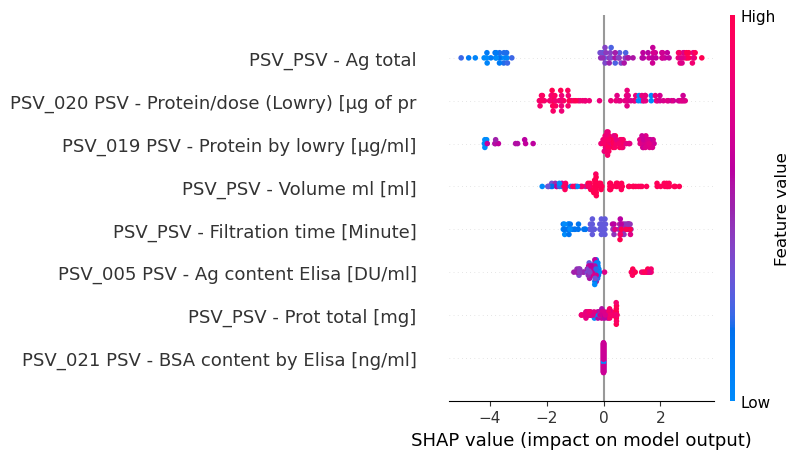

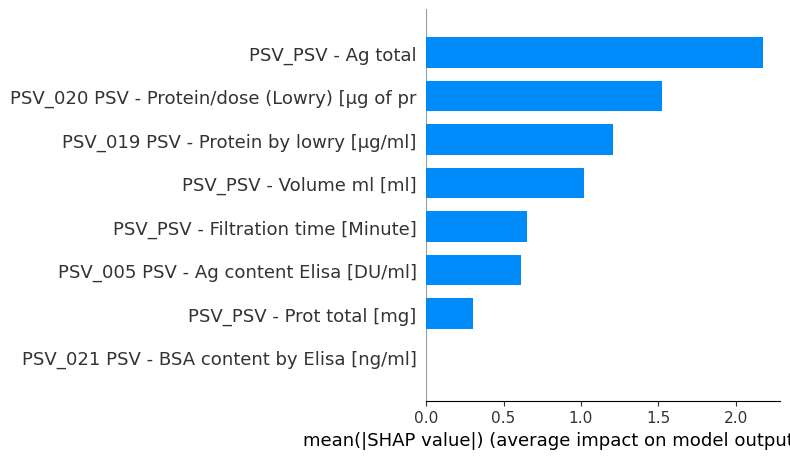

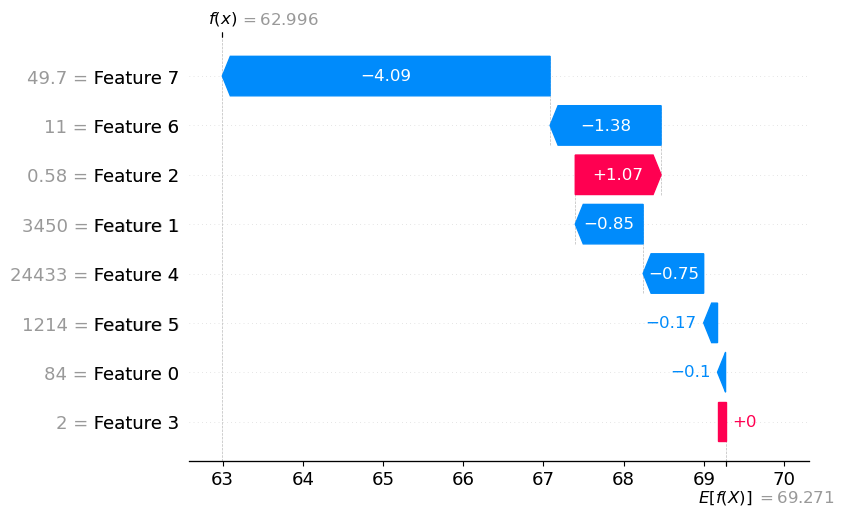

In [221]:
explainer_hgb_psv   = shap.TreeExplainer(final_hgb_psv)
shap_values_hgb_psv = explainer_hgb_psv.shap_values(X_final)

feature_names = best_features_psv["HGB"]

# Summary plot: shows feature importance + direction of effect
shap.summary_plot(shap_values_hgb_psv, X_final, feature_names=feature_names)

# Bar plot: mean absolute SHAP value per feature (cleaner for reports)
shap.summary_plot(shap_values_hgb_psv, X_final, feature_names=feature_names, plot_type="bar")

# Single prediction explanation: useful for the dashboard
shap.waterfall_plot(explainer_hgb_psv(X_final)[0])  # explains first observation

---

## IP1 Global Yield

In [ ]:
# Workaround, remember to change it back:
STAGE_TARGETS = {
    "global": TARGET
}

In [ ]:
THRESHOLDS =[0.096, 0.097, 0.0981, 0.1, 0.101, 0.15, 0.199]
best_features_global = tune_threshold("global", df_ip1, "IP1", THRESHOLDS, all_feature_list=all_feature_list_global)

[global] 220 features selected with Abs_r >= 0.096
STAGE: GLOBAL  |  target: GY_011 PSV - Global Yield total [%]
Features: 220
  n=88 observations

  Model                 Train R²   LOO R²     Diff   LOO RMSE    NRMSE   LOO MAE
  --------------------------------------------------------------------------------
  OLS                     1.0000   0.3528   0.6472    2.541pp    0.071    1.379pp
  HGB                     0.9365   0.6746   0.2619    1.801pp    0.051    1.372pp
  RandomForest            0.5451   0.1438   0.4013    2.922pp    0.082    2.319pp
[global] 214 features selected with Abs_r >= 0.097
STAGE: GLOBAL  |  target: GY_011 PSV - Global Yield total [%]
Features: 214
  n=88 observations

  Model                 Train R²   LOO R²     Diff   LOO RMSE    NRMSE   LOO MAE
  --------------------------------------------------------------------------------
  OLS                     1.0000  -0.7379   1.7379    4.163pp    0.117    2.093pp
  HGB                     0.9370   0.6837   0.25

### Hyperparameter tune HGB

In [156]:
# Run best_hgb_optuna()
best_hgb_global, study_global = tune_hgb_optuna(
    stage_name  = "global",
    target      = TARGET,
    features    = best_features_global["HGB"],
    df          = df_ip1,
    n_trials    = 100,
    diff_weight = 0.5,
)


OPTUNA HGB: GLOBAL
  Best score     : 0.6669
  Best params    : {'max_iter': 194, 'max_depth': 2, 'learning_rate': 0.08889152078214738, 'min_samples_leaf': 7, 'l2_regularization': 0.1634033519429708, 'max_features': 0.9290024730027897}
  Train R²       : 0.9991
  LOO R²         : 0.7776
  Diff           : 0.2214
  RMSE           : 1.4891
  NRMSE          : 0.0419
  MAE            : 1.0865


In [172]:
best_rf_global, study_rf_global = tune_rf_optuna(
    stage_name  = "global",
    target      = TARGET,
    features    = best_features_global["RandomForest"],
    df          = df_ip1,
    n_trials    = 50,
    diff_weight = 0.5,
)


OPTUNA RF -> GLOBAL
  Best score     : 0.2644
  Best params    : {'n_estimators': 161, 'max_depth': 4, 'min_samples_leaf': 9, 'min_samples_split': 2, 'max_features': 0.5}
  Train R²       : 0.5792
  LOO R²         : 0.3693
  Diff           : 0.2098
  RMSE           : 2.5078pp
  NRMSE          : 0.0705
  MAE            : 1.9964pp


Sanity check, shuffle "y" randomly, R^2 should collapse to ~0

In [171]:
shuffled_r2s = []
for i in range(10):
    y_shuffled = np.random.permutation(df_ip1[TARGET])
    y_pred_shuffled = cross_val_predict(best_hgb_global, df_ip1[best_features_global["HGB"]], y_shuffled, cv=LeaveOneOut())
    shuffled_r2s.append(r2_score(y_shuffled, y_pred_shuffled))

print(f"Shuffled R² across 10 runs: mean={np.mean(shuffled_r2s):.4f}, std={np.std(shuffled_r2s):.4f}")  # should be near 0

Shuffled R² across 10 runs: mean=-0.3361, std=0.1809


Close enough to 0, so the LOO-CV is working correctly and is not a result of leakage. Therfore, the model is genuinely learning signal from the features, not exploiting some structural artifact.

#### STOP To check Global Model

### Final Run and Global Model Export

In [231]:
# Best params found by Optuna are stored in study.best_params
final_hgb_global = HistGradientBoostingRegressor(**study_global.best_params, random_state=42)

df_work = df_ip1[best_features_global["HGB"] + [TARGET]].copy()
df_work = df_work[df_work[TARGET].notna()].reset_index(drop=True)
X_final = df_work[best_features_global["HGB"]].values
y_final = df_work[TARGET].values

final_hgb_global.fit(X_final, y_final)
print("Final model trained on all 88 observations ✓")

Final model trained on all 88 observations ✓


In [235]:
loo    = LeaveOneOut()
y_cv   = cross_val_predict(final_hgb_global, X_final, y_final, cv=loo)
tr     = r2_score(y_final, final_hgb_global.predict(X_final))
loo_r2 = r2_score(y_final, y_cv)
diff   = tr - loo_r2
rmse   = np.sqrt(mean_squared_error(y_final, y_cv))
nrmse  = rmse / y_final.mean()
mae    = mean_absolute_error(y_final, y_cv)

print(f"\nTrain R²: {tr:.4f}")
print(f"LOO R²  : {loo_r2:.4f}")
print(f"Diff    : {diff:.4f}")
print(f"RMSE    : {rmse:.4f}pp")
print(f"NRMSE   : {nrmse:.4f}")
print(f"MAE     : {mae:.4f}pp")


Train R²: 0.9991
LOO R²  : 0.7776
Diff    : 0.2214
RMSE    : 1.4891pp
NRMSE   : 0.0419
MAE     : 1.0865pp


In [227]:
# Save model and feature list together so we know what columns to pass on Dashboard
joblib.dump({
    "model":    final_hgb_global,
    "features": best_features_global["HGB"],
    "target":   TARGET,
}, "C:/Hackathon-GSK/outputs/models/IP1_hgb_global_model.pkl")

print("Model saved to IP1_hgb_global_model.pkl ✓")

Model saved to IP1_hgb_global_model.pkl ✓


to import it, run something like

```
import joblib

bundle = joblib.load("C:/Hackathon-GSK/outputs/models/IP1_global_model.pkl")
model    = bundle["model"]
features = bundle["features"]
target   = bundle["target"]

# Predict on new data
y_pred = model.predict(new_df[features].values)
```

### SHAP Global Values

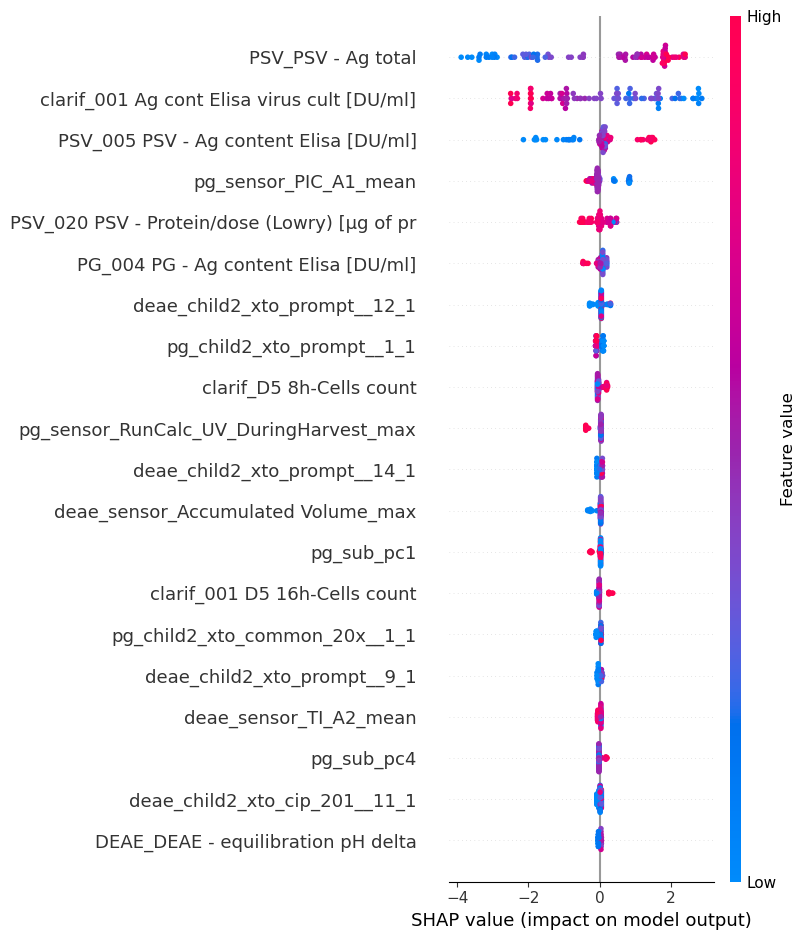

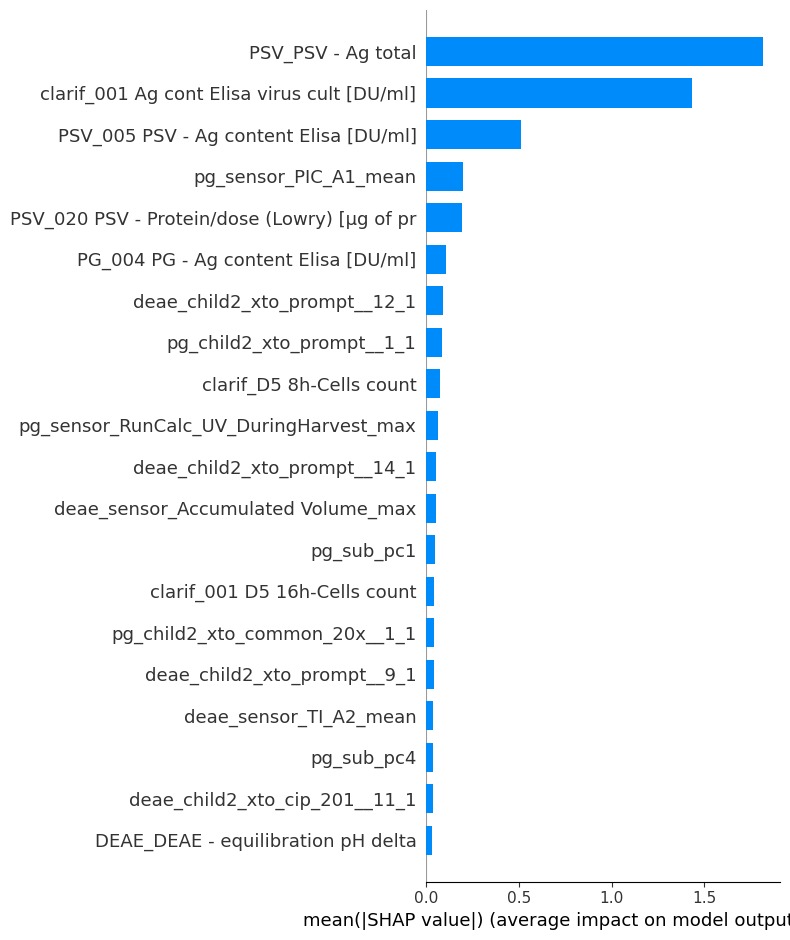

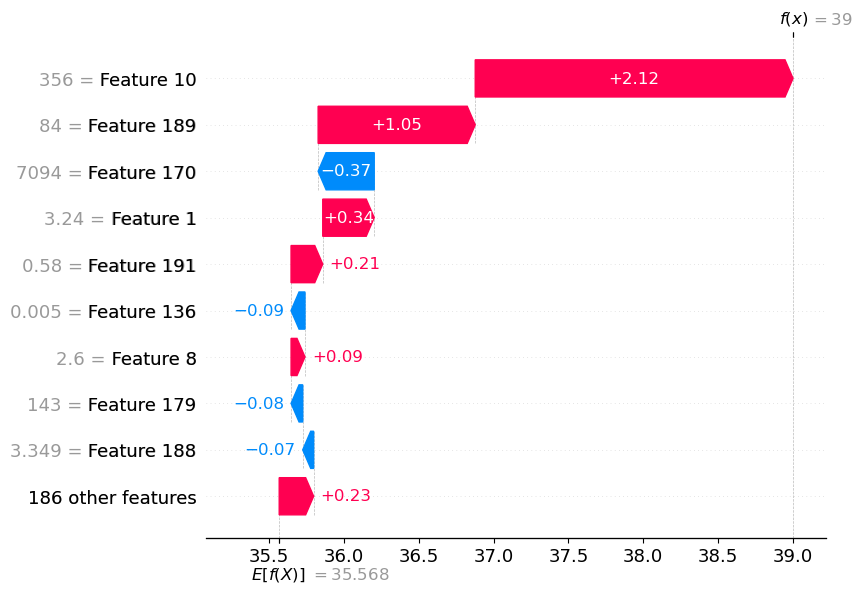

In [232]:
explainer_hgb_global   = shap.TreeExplainer(final_hgb_global)
shap_values_hgb_global = explainer_hgb_global.shap_values(X_final)

feature_names = best_features_global["HGB"]

# Summary plot: shows feature importance + direction of effect
shap.summary_plot(shap_values_hgb_global, X_final, feature_names=feature_names)

# Bar plot: mean absolute SHAP value per feature (cleaner for reports)
shap.summary_plot(shap_values_hgb_global, X_final, feature_names=feature_names, plot_type="bar")

# Single prediction explanation: useful for the dashboard
shap.waterfall_plot(explainer_hgb_global(X_final)[0])  # explains first observation

### Export RF and OLS models as well:

In [236]:
# Best params found by Optuna are stored in study.best_params
final_rf_global = RandomForestRegressor(**{**study_rf_global.best_params, "random_state": 42})

df_work = df_ip1[best_features_global["RandomForest"] + [TARGET]].copy()
df_work = df_work[df_work[TARGET].notna()].reset_index(drop=True)
X_final = df_work[best_features_global["RandomForest"]].values
y_final = df_work[TARGET].values

final_rf_global.fit(X_final, y_final)
print("Final model trained on all 88 observations ✓")

joblib.dump({
    "model":    final_rf_global,
    "features": best_features_global["RandomForest"],
    "target":   TARGET,
}, "C:/Hackathon-GSK/outputs/models/IP1_rf_global_model.pkl")

print("Model saved to IP1_rf_global_model.pkl ✓")

Final model trained on all 88 observations ✓
Model saved to IP1_hgb_rf_global_model.pkl ✓


In [237]:
final_ols_global = LinearRegression()

df_work = df_ip1[best_features_global["OLS"] + [TARGET]].copy()
df_work = df_work[df_work[TARGET].notna()].reset_index(drop=True)
X_final = df_work[best_features_global["OLS"]].values
y_final = df_work[TARGET].values

final_ols_global.fit(X_final, y_final)
print("Final model trained on all 88 observations ✓")

joblib.dump({
    "model":    final_ols_global,
    "features": best_features_global["OLS"],
    "target":   TARGET,
}, "C:/Hackathon-GSK/outputs/models/IP1_ols_global_model.pkl")

print("Model saved to IP1_ols_global_model.pkl ✓")

Final model trained on all 88 observations ✓
Model saved to IP1_ols_global_model.pkl ✓


In [158]:
#reset the STAGE_TARGETS object in case we need it later THIS IS PART OF THE WORKAROUND MENTIONED ABOVE
STAGE_TARGETS = {
    "clarif":     "clarif_007 Clarif - Yield total [%]",
    "uf":         "UF_008 UF - Yield [%]",
    "pg":         "PG_009 PG - Yield [%]",
    "psv_global": "PSV_010 PSV - Yield [%]",
}

## IP3

### Setup: Feature Engineering

In [ ]:
SEROTYPE = "IP3"
STAGE_TARGETS = {
    "clarif":     "clarif_007 Clarif - Yield total [%]",
    "uf":         "UF_008 UF - Yield [%]",
    "pg":         "PG_009 PG - Yield [%]",
    "psv_global": "PSV_010 PSV - Yield [%]",
}

def engineer_features(df):
    d = df.copy()

    # ── CLARIF ────────────────────────────────────────────────────────────────
    # Strongest clarif signals: Ag content (r=-0.41), D5 cells (r=+0.25), Duration (r=+0.22)
    d["eng4_clarif_ag_x_duration"] = (
        d["clarif_001 Ag cont Elisa virus cult [DU/ml]"] *
        d["clarif_Duration cells pool transfer [Minute]"]
    )
    d["eng4_clarif_cells_x_duration"] = (
        d["clarif_D5 8h-Cells count"] *
        d["clarif_Duration cells pool transfer [Minute]"]
    )
    d["eng4_clarif_d0_x_d5"] = (
        d["clarif_D0-Cells count"] *
        d["clarif_D5 8h-Cells count"]
    )
    d["eng4_clarif_protein_x_duration"] = (
        d["clarif_014 Protein Lowry virus cult [µg/ml]"] *
        d["clarif_Duration cells pool transfer [Minute]"]
    )
    d["eng4_clarif_ag_x_flow340"] = (
        d["clarif_001 Ag cont Elisa virus cult [DU/ml]"] *
        d["clarif_Clarif 1 - Flow 340L (L/min)"]
    )

    # ── UF ────────────────────────────────────────────────────────────────────
    # Strongest UF signals: Ag total (r=+0.51), Ag content ELISA (r=+0.43)
    d["eng4_uf_ag_elisa_x_total"] = (
        d["UF_003 UF - Ag content Elisa [DU/ml]"] *
        d["UF_UF - Ag total"]
    )
    d["eng4_uf_ag_x_volume"] = (
        d["UF_UF - Ag total"] *
        d["UF_UF - Volume UFR ml [ml]"]
    )
    d["eng4_uf_elisa_x_volume"] = (
        d["UF_003 UF - Ag content Elisa [DU/ml]"] *
        d["UF_UF - Volume UFR ml [ml]"]
    )

    # ── PG ────────────────────────────────────────────────────────────────────
    # Strongest PG signals: Ag content (r=+0.39), packing, temperature, XV valve
    d["eng4_pg_ag_x_packing_s1"] = (
        d["PG_004 PG - Ag content Elisa [DU/ml]"] *
        d["PG_Packing quality HETP/S1 [Centimeter]"]
    )
    d["eng4_pg_ag_x_packing_s2"] = (
        d["PG_004 PG - Ag content Elisa [DU/ml]"] *
        d["PG_Packing quality HETP/S2 [Centimeter]"]
    )
    d["eng4_pg_temp_x_xv"] = (
        d["pg_sensor_TI_A2_max"] *
        d["pg_sensor_XV-O1_ZSO_mean"]
    )
    d["eng4_pg_ag_x_accumulated_vol"] = (
        d["PG_PG - Ag total"] *
        d["pg_sensor_Accumulated Volume_max"]
    )
    d["eng4_pg_fic_x_pic"] = (
        d["pg_sensor_FIC_C11_mean"] *
        d["pg_sensor_PIC_A1_mean"]
    )
    d["eng4_pg_ti_a1_x_ti_a2"] = (
        d["pg_sensor_TI_A1_mean"] *
        d["pg_sensor_TI_A2_mean"]
    )
    d["eng4_pg_uv_x_pi"] = (
        d["pg_sensor_UV Light_std"] *
        d["pg_sensor_PI_A2_mean"]
    )
    d["eng4_pg_ai_a2_x_accumulated"] = (
        d["pg_sensor_AI_A2_mean"] *
        d["pg_sensor_Accumulated Volume_max"]
    )
    d["eng4_pg_xv_x_uv_harvest"] = (
        d["pg_sensor_XV-O1_ZSO_std"] *
        d["pg_sensor_RunCalc_UV_DuringHarvest_max"]
    )

    # ── PSV ───────────────────────────────────────────────────────────────────
    # Strongest PSV signals: Ag total (r=+0.55), Ag ELISA (r=+0.47), Volume (r=+0.33)
    d["eng4_psv_ag_x_elisa"] = (
        d["PSV_PSV - Ag total"] *
        d["PSV_005 PSV - Ag content Elisa [DU/ml]"]
    )
    d["eng4_psv_ag_x_volume"] = (
        d["PSV_PSV - Ag total"] *
        d["PSV_PSV - Volume ml [ml]"]
    )
    d["eng4_psv_elisa_x_prot"] = (
        d["PSV_005 PSV - Ag content Elisa [DU/ml]"] *
        d["PSV_PSV - Prot total [mg]"]
    )
    d["eng4_psv_ag_x_prot"] = (
        d["PSV_PSV - Ag total"] /
        (d["PSV_PSV - Prot total [mg]"] + 1e-9)
    )

    return d

# 1. Apply feature engineering to dataframe first
df_ip3_eng = engineer_features(df_ip3)
print(f"  Engineered cols: {[c for c in df_ip3_eng.columns if c.startswith('eng4_')]}")

  Engineered cols: []


### Clarification

In [ ]:
THRESHOLDS =[0.12, 0.125, 0.128, 0.15, 0.2]
ip3_best_features_clarif = tune_threshold("clarif", df_ip3, "IP3", THRESHOLDS, all_feature_list=all_feature_list)

[clarif] 19 features selected with Abs_r >= 0.12
[uf] 3 features selected with Abs_r >= 0.12
[pg] 67 features selected with Abs_r >= 0.12
[psv_global] 7 features selected with Abs_r >= 0.12
STAGE: CLARIF  |  target: clarif_007 Clarif - Yield total [%]
Features: 19
  n=87 observations

  Model                 Train R²   LOO R²     Diff   LOO RMSE    NRMSE   LOO MAE
  --------------------------------------------------------------------------------
  OLS                     0.4602   0.1052   0.3550    6.708pp    0.106    5.387pp
  HGB                     0.6443   0.0752   0.5691    6.820pp    0.108    5.442pp
  RandomForest            0.3941   0.1019   0.2922    6.720pp    0.106    5.435pp
[clarif] 18 features selected with Abs_r >= 0.125
[uf] 3 features selected with Abs_r >= 0.125
[pg] 63 features selected with Abs_r >= 0.125
[psv_global] 7 features selected with Abs_r >= 0.125
STAGE: CLARIF  |  target: clarif_007 Clarif - Yield total [%]
Features: 18
  n=87 observations

  Model       

In [244]:
eng_clarif = ['eng4_clarif_protein_x_duration', 'eng4_clarif_ag_x_duration', 'eng4_clarif_cells_x_duration', 'eng4_clarif_d0_x_d5']

for model in ip3_best_features_clarif:
    ip3_best_features_clarif[model] = list(dict.fromkeys(ip3_best_features_clarif[model] + eng_clarif))

#### Hyperparameter tuning HGB and RF

In [246]:
ip3_best_hgb_clarif, ip3_study_hgb_clarif = tune_hgb_optuna(
    stage_name  = "clarif",
    target      = STAGE_TARGETS["clarif"],
    features    = ip3_best_features_clarif["HGB"],
    df          = df_ip3_eng,
    n_trials    = 100,
    diff_weight = 0.5,
)


OPTUNA HGB: CLARIF
  Best score     : 0.0995
  Best params    : {'max_iter': 63, 'max_depth': 5, 'learning_rate': 0.026304206931592956, 'min_samples_leaf': 27, 'l2_regularization': 2.8904743585739334, 'max_features': 0.6088885664758784}
  Train R²       : 0.2544
  LOO R²         : 0.1511
  Diff           : 0.1033
  RMSE           : 6.5336
  NRMSE          : 0.1030
  MAE            : 5.2594


In [247]:
ip3_best_rf_clarif, ip3_study_rf_clarif = tune_rf_optuna(
    stage_name  = "clarif",
    target      = STAGE_TARGETS["clarif"],
    features    = ip3_best_features_clarif["RandomForest"],
    df          = df_ip3_eng,
    n_trials    = 50,
    diff_weight = 0.5,
)


OPTUNA RF -> CLARIF
  Best score     : 0.0560
  Best params    : {'n_estimators': 181, 'max_depth': 4, 'min_samples_leaf': 19, 'min_samples_split': 12, 'max_features': 0.5}
  Train R²       : 0.2112
  LOO R²         : 0.1077
  Diff           : 0.1035
  RMSE           : 6.6986pp
  NRMSE          : 0.1057
  MAE            : 5.3610pp


#### STOP To check Clarif

In [248]:
# Best params found by Optuna are stored in study.best_params
ip3_final_ols_clarif = LinearRegression()

df_work = df_ip3_eng[ip3_best_features_clarif["OLS"] + [STAGE_TARGETS["clarif"]]].copy()
df_work = df_work[df_work[STAGE_TARGETS["clarif"]].notna()].reset_index(drop=True)
X_final = df_work[ip3_best_features_clarif["OLS"]].values
y_final = df_work[STAGE_TARGETS["clarif"]].values

ip3_final_ols_clarif.fit(X_final, y_final)
print("Final model trained on all 88 observations ✓")

########################################################

loo    = LeaveOneOut()
y_cv   = cross_val_predict(ip3_final_ols_clarif, X_final, y_final, cv=loo)
tr     = r2_score(y_final, ip3_final_ols_clarif.predict(X_final))
loo_r2 = r2_score(y_final, y_cv)
diff   = tr - loo_r2
rmse   = np.sqrt(mean_squared_error(y_final, y_cv))
nrmse  = rmse / y_final.mean()
mae    = mean_absolute_error(y_final, y_cv)

print(f"\nTrain R²: {tr:.4f}")
print(f"LOO R²  : {loo_r2:.4f}")
print(f"Diff    : {diff:.4f}")
print(f"RMSE    : {rmse:.4f}pp")
print(f"NRMSE   : {nrmse:.4f}")
print(f"MAE     : {mae:.4f}pp")

########################################################

# Save model and feature list together so we know what columns to pass on Dashboard
joblib.dump({
    "model":    ip3_final_ols_clarif,
    "features": ip3_best_features_clarif["OLS"],
    "target":   STAGE_TARGETS["clarif"],
}, "C:/Hackathon-GSK/outputs/models/IP3_clarif_model.pkl")

print("\nModel saved to IP3_clarif_model.pkl ✓")

Final model trained on all 88 observations ✓

Train R²: 0.3646
LOO R²  : 0.0497
Diff    : 0.3149
RMSE    : 6.9127pp
NRMSE   : 0.1090
MAE     : 5.5745pp

Model saved to IP3_clarif_model.pkl ✓


#### SHAP Clarif

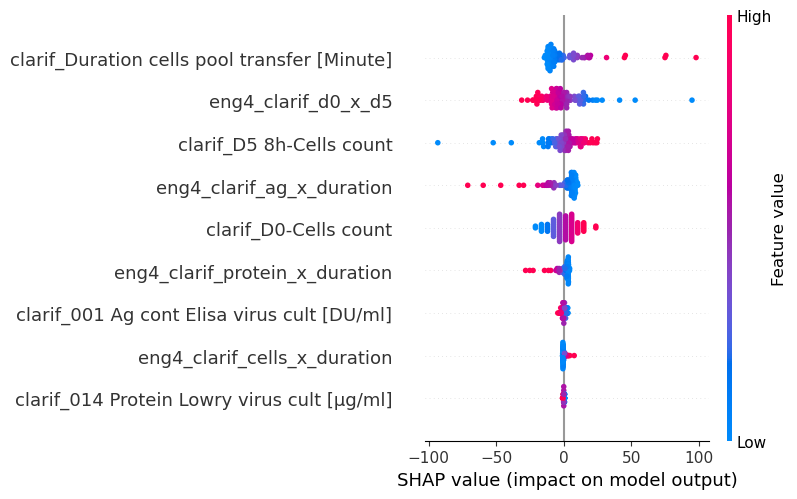

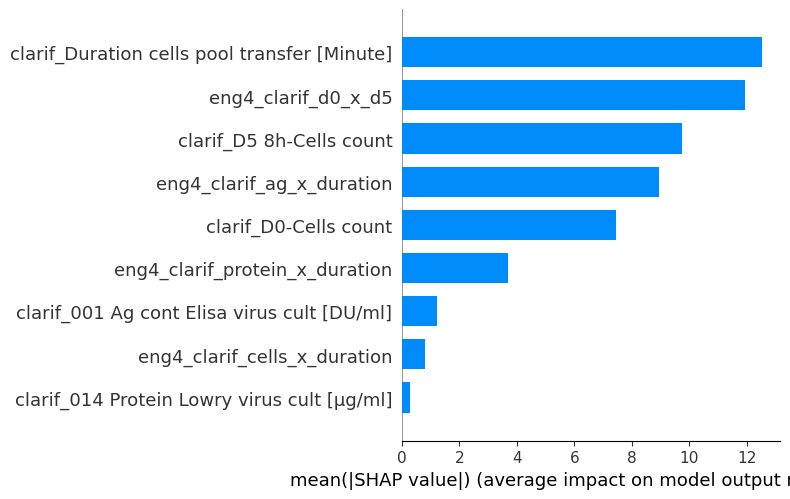

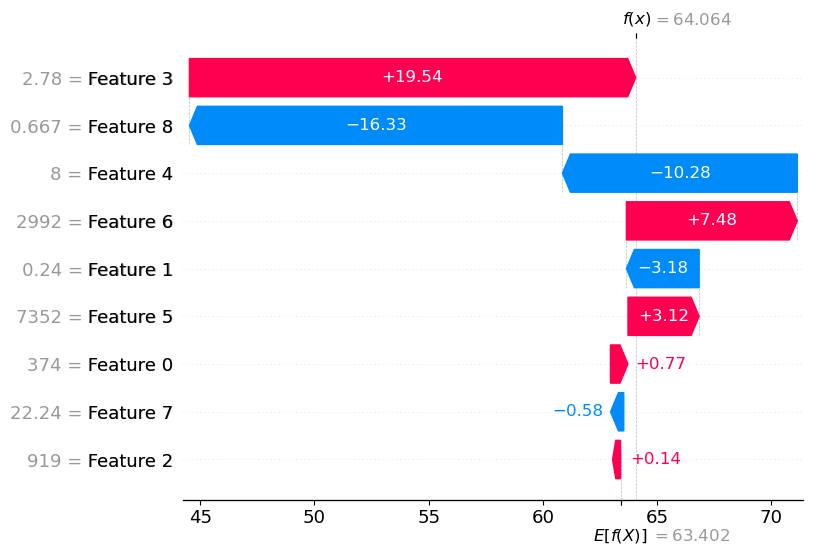

In [249]:
ip3_explainer_ols = shap.LinearExplainer(ip3_final_ols_clarif, X_final)
ip3_shap_values_ols = ip3_explainer_ols.shap_values(X_final)

feature_names = ip3_best_features_clarif["OLS"]  # swap for the relevant feature list

# Summary plot: shows feature importance + direction of effect
shap.summary_plot(ip3_shap_values_ols, X_final, feature_names=feature_names)

# Bar plot: mean absolute SHAP value per feature (cleaner for reports)
shap.summary_plot(ip3_shap_values_ols, X_final, feature_names=feature_names, plot_type="bar")

# Single prediction explanation: useful for the dashboard
shap.waterfall_plot(ip3_explainer_ols(X_final)[0])  # explains first observation

### UF

In [ ]:
THRESHOLDS = [0.003,0.005, 0.008, 0.03, 0.05, 0.09, 0.1, 0.15, 0.17, 0.199]
ip3_best_features_uf = tune_threshold("uf", df_ip3_eng, "IP3", THRESHOLDS, all_feature_list=all_feature_list)

[clarif] 34 features selected with Abs_r >= 0.003
[uf] 6 features selected with Abs_r >= 0.003
[pg] 241 features selected with Abs_r >= 0.003
[psv_global] 9 features selected with Abs_r >= 0.003
STAGE: UF  |  target: UF_008 UF - Yield [%]
Features: 6
  n=87 observations

  Model                 Train R²   LOO R²     Diff   LOO RMSE    NRMSE   LOO MAE
  --------------------------------------------------------------------------------
  OLS                     0.3196   0.1496   0.1700   10.416pp    0.111    8.070pp
  HGB                     0.5853   0.0635   0.5217   10.931pp    0.117    8.880pp
  RandomForest            0.4212   0.1381   0.2832   10.487pp    0.112    7.965pp
[clarif] 32 features selected with Abs_r >= 0.005
[uf] 6 features selected with Abs_r >= 0.005
[pg] 236 features selected with Abs_r >= 0.005
[psv_global] 9 features selected with Abs_r >= 0.005
STAGE: UF  |  target: UF_008 UF - Yield [%]
Features: 6
  n=87 observations

  Model                 Train R²   LOO R²     

In [251]:
eng_uf = ['eng4_uf_ag_x_volume', 'eng4_uf_elisa_x_volume', 'eng4_uf_ag_elisa_x_total']

for model in ip3_best_features_uf:
    ip3_best_features_uf[model] = list(dict.fromkeys(ip3_best_features_uf[model] + eng_uf))

#### Hyperparameter tuning HGB & RF

In [252]:
ip3_best_hgb_uf, ip3_study_hgb_uf = tune_hgb_optuna(
    stage_name  = "uf",
    target      = STAGE_TARGETS["uf"],
    features    = ip3_best_features_uf["HGB"],
    df          = df_ip3_eng,
    n_trials    = 100,
    diff_weight = 0.5,
)


OPTUNA HGB: UF
  Best score     : 0.1201
  Best params    : {'max_iter': 95, 'max_depth': 4, 'learning_rate': 0.03344554180674478, 'min_samples_leaf': 14, 'l2_regularization': 4.38549051864031, 'max_features': 0.3077148881522498}
  Train R²       : 0.4915
  LOO R²         : 0.2439
  Diff           : 0.2476
  RMSE           : 9.8222
  NRMSE          : 0.1049
  MAE            : 7.5693


In [253]:
ip3_best_rf_uf, ip3_study_rf_uf = tune_rf_optuna(
    stage_name  = "uf",
    target      = STAGE_TARGETS["uf"],
    features    = ip3_best_features_uf["RandomForest"],
    df          = df_ip3_eng,
    n_trials    = 50,
    diff_weight = 0.5,
)


OPTUNA RF -> UF
  Best score     : 0.0953
  Best params    : {'n_estimators': 278, 'max_depth': 5, 'min_samples_leaf': 9, 'min_samples_split': 4, 'max_features': 'log2'}
  Train R²       : 0.3750
  LOO R²         : 0.1885
  Diff           : 0.1865
  RMSE           : 10.1754pp
  NRMSE          : 0.1087
  MAE            : 7.7276pp


#### STOP To check UF

In [254]:
# Best params found by Optuna are stored in study.best_params
ip3_final_rf_uf = RandomForestRegressor(**{**ip3_study_rf_uf.best_params, "random_state": 42})

df_work = df_ip3_eng[ip3_best_features_uf["RandomForest"] + [STAGE_TARGETS["uf"]]].copy()
df_work = df_work[df_work[STAGE_TARGETS["uf"]].notna()].reset_index(drop=True)
X_final = df_work[ip3_best_features_uf["RandomForest"]].values
y_final = df_work[STAGE_TARGETS["uf"]].values

ip3_final_rf_uf.fit(X_final, y_final)
print("Final model trained on all 88 observations ✓")

########################################################

loo    = LeaveOneOut()
y_cv   = cross_val_predict(ip3_final_rf_uf, X_final, y_final, cv=loo)
tr     = r2_score(y_final, ip3_final_rf_uf.predict(X_final))
loo_r2 = r2_score(y_final, y_cv)
diff   = tr - loo_r2
rmse   = np.sqrt(mean_squared_error(y_final, y_cv))
nrmse  = rmse / y_final.mean()
mae    = mean_absolute_error(y_final, y_cv)

print(f"\nTrain R²: {tr:.4f}")
print(f"LOO R²  : {loo_r2:.4f}")
print(f"Diff    : {diff:.4f}")
print(f"RMSE    : {rmse:.4f}pp")
print(f"NRMSE   : {nrmse:.4f}")
print(f"MAE     : {mae:.4f}pp")

########################################################

# Save model and feature list together so we know what columns to pass on Dashboard
joblib.dump({
    "model":    ip3_final_rf_uf,
    "features": ip3_best_features_uf["RandomForest"],
    "target":   STAGE_TARGETS["uf"],
}, "C:/Hackathon-GSK/outputs/models/IP3_uf_model.pkl")

print("\nModel saved to IP3_uf_model.pkl ✓")

Final model trained on all 88 observations ✓

Train R²: 0.3750
LOO R²  : 0.1885
Diff    : 0.1865
RMSE    : 10.1754pp
NRMSE   : 0.1087
MAE     : 7.7276pp

Model saved to IP3_uf_model.pkl ✓


#### SHAP UF

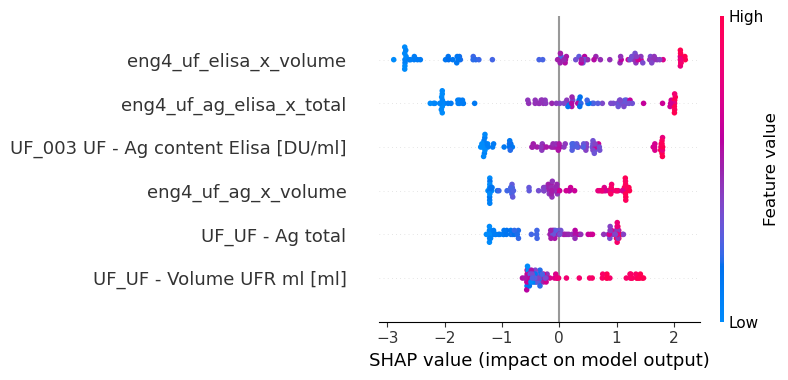

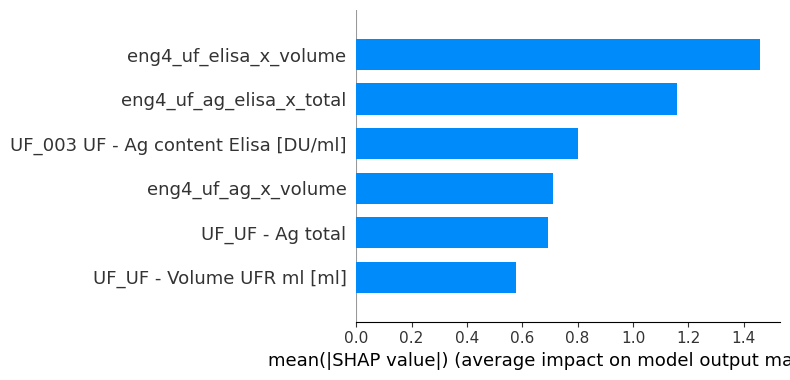

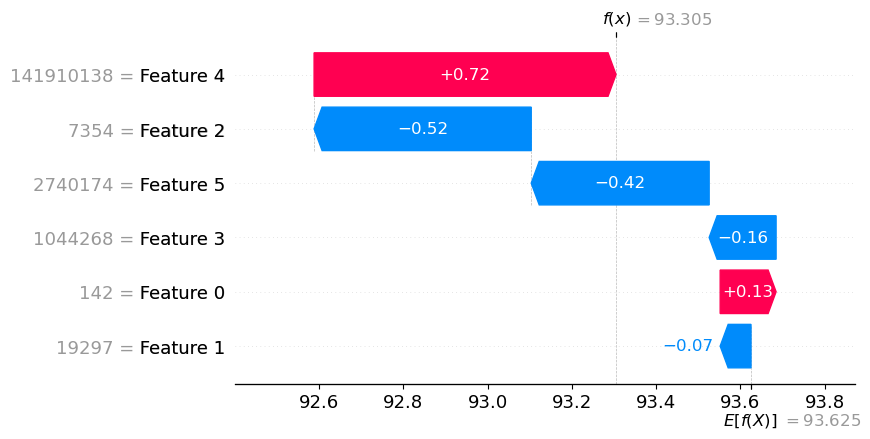

In [255]:
ip3_explainer_rf  = shap.TreeExplainer(ip3_final_rf_uf)
ip3_shap_values_rf = ip3_explainer_rf.shap_values(X_final)

feature_names = ip3_best_features_uf["RandomForest"]

# Summary plot: shows feature importance + direction of effect
shap.summary_plot(ip3_shap_values_rf, X_final, feature_names=feature_names)

# Bar plot: mean absolute SHAP value per feature (cleaner for reports)
shap.summary_plot(ip3_shap_values_rf, X_final, feature_names=feature_names, plot_type="bar")

# Single prediction explanation: useful for the dashboard
shap.waterfall_plot(ip3_explainer_rf(X_final)[0])  # explains first observation

### PG

In [ ]:
THRESHOLDS = [0.042, 0.05, 0.19, 0.2, 0.2273, 0.29, 0.3, 0.315]
ip3_best_features_pg = tune_threshold("pg", df_ip3_eng, "IP3", THRESHOLDS, all_feature_list=all_feature_list)

[clarif] 28 features selected with Abs_r >= 0.042
[uf] 5 features selected with Abs_r >= 0.042
[pg] 171 features selected with Abs_r >= 0.042
[psv_global] 9 features selected with Abs_r >= 0.042
STAGE: PG  |  target: PG_009 PG - Yield [%]
Features: 171
  n=87 observations

  Model                 Train R²   LOO R²     Diff   LOO RMSE    NRMSE   LOO MAE
  --------------------------------------------------------------------------------
  OLS                     1.0000 -32678.4616 32679.4616  958.923pp   12.454  146.593pp
  HGB                     0.8162   0.1672   0.6491    4.841pp    0.063    3.799pp
  RandomForest            0.4557   0.0148   0.4409    5.265pp    0.068    4.070pp
[clarif] 28 features selected with Abs_r >= 0.05
[uf] 5 features selected with Abs_r >= 0.05
[pg] 158 features selected with Abs_r >= 0.05
[psv_global] 8 features selected with Abs_r >= 0.05
STAGE: PG  |  target: PG_009 PG - Yield [%]
Features: 158
  n=87 observations

  Model                 Train R²   LOO R²

In [257]:
eng_pg = ['eng4_pg_ag_x_packing_s1', 'eng4_pg_ag_x_packing_s2', 'eng4_pg_xv_x_uv_harvest', 'eng4_pg_ti_a1_x_ti_a2', 'eng4_pg_ag_x_accumulated_vol']

for model in ip3_best_features_pg:
    ip3_best_features_pg[model] = list(dict.fromkeys(ip3_best_features_pg[model] + eng_pg))

#### Hyperparameter tune HGB & RF

In [258]:
ip3_best_hgb_pg, ip3_study_hgb_pg = tune_hgb_optuna(
    stage_name  = "pg",
    target      = STAGE_TARGETS["pg"],
    features    = ip3_best_features_pg["HGB"],
    df          = df_ip3_eng,
    n_trials    = 100,
    diff_weight = 0.5,
)


OPTUNA HGB: PG
  Best score     : 0.1020
  Best params    : {'max_iter': 97, 'max_depth': 2, 'learning_rate': 0.016571423780100653, 'min_samples_leaf': 6, 'l2_regularization': 9.70041300822922, 'max_features': 0.8604405405055823}
  Train R²       : 0.3246
  LOO R²         : 0.1762
  Diff           : 0.1484
  RMSE           : 4.8146
  NRMSE          : 0.0625
  MAE            : 3.7285


In [259]:
ip3_best_rf_pg, ip3_study_rf_pg = tune_rf_optuna(
    stage_name  = "pg",
    target      = STAGE_TARGETS["pg"],
    features    = ip3_best_features_pg["RandomForest"],
    df          = df_ip3_eng,
    n_trials    = 50,
    diff_weight = 0.5,
)


OPTUNA RF -> PG
  Best score     : 0.0297
  Best params    : {'n_estimators': 229, 'max_depth': 3, 'min_samples_leaf': 17, 'min_samples_split': 14, 'max_features': 'log2'}
  Train R²       : 0.2128
  LOO R²         : 0.0908
  Diff           : 0.1220
  RMSE           : 5.0580pp
  NRMSE          : 0.0657
  MAE            : 3.8517pp


#### STOP to check PG

In [260]:
# Best params found by Optuna are stored in study.best_params
ip3_final_hgb_pg = HistGradientBoostingRegressor(**{**ip3_study_hgb_pg.best_params, "random_state": 42})

df_work = df_ip3_eng[ip3_best_features_pg["HGB"] + [STAGE_TARGETS["pg"]]].copy()
df_work = df_work[df_work[STAGE_TARGETS["pg"]].notna()].reset_index(drop=True)
X_final = df_work[ip3_best_features_pg["HGB"]].values
y_final = df_work[STAGE_TARGETS["pg"]].values

ip3_final_hgb_pg.fit(X_final, y_final)
print("Final model trained on all 88 observations ✓")

########################################################

loo    = LeaveOneOut()
y_cv   = cross_val_predict(ip3_final_hgb_pg, X_final, y_final, cv=loo)
tr     = r2_score(y_final, ip3_final_hgb_pg.predict(X_final))
loo_r2 = r2_score(y_final, y_cv)
diff   = tr - loo_r2
rmse   = np.sqrt(mean_squared_error(y_final, y_cv))
nrmse  = rmse / y_final.mean()
mae    = mean_absolute_error(y_final, y_cv)

print(f"\nTrain R²: {tr:.4f}")
print(f"LOO R²  : {loo_r2:.4f}")
print(f"Diff    : {diff:.4f}")
print(f"RMSE    : {rmse:.4f}pp")
print(f"NRMSE   : {nrmse:.4f}")
print(f"MAE     : {mae:.4f}pp")

########################################################

# Save model and feature list together so we know what columns to pass on Dashboard
joblib.dump({
    "model":    ip3_final_hgb_pg,
    "features": ip3_best_features_pg["HGB"],
    "target":   STAGE_TARGETS["pg"],
}, "C:/Hackathon-GSK/outputs/models/IP3_pg_model.pkl")

print("\nModel saved to IP3_pg_model.pkl ✓")

Final model trained on all 88 observations ✓

Train R²: 0.3246
LOO R²  : 0.1762
Diff    : 0.1484
RMSE    : 4.8146pp
NRMSE   : 0.0625
MAE     : 3.7285pp

Model saved to IP3_pg_model.pkl ✓


#### SHAP HGB

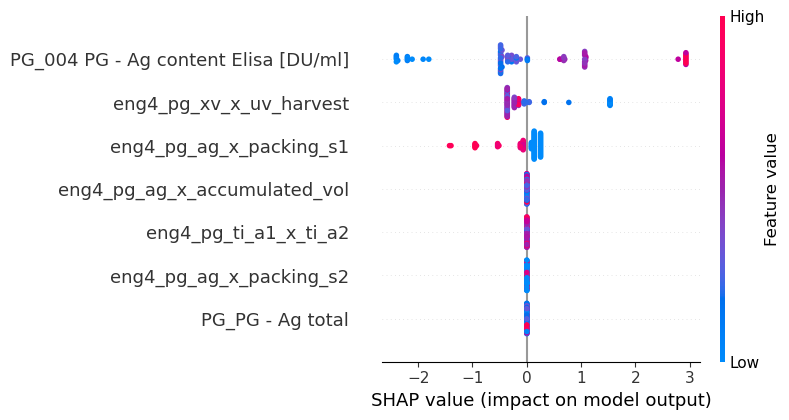

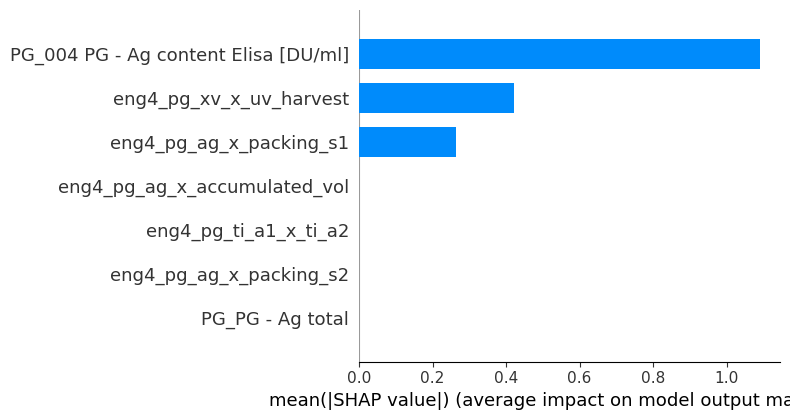

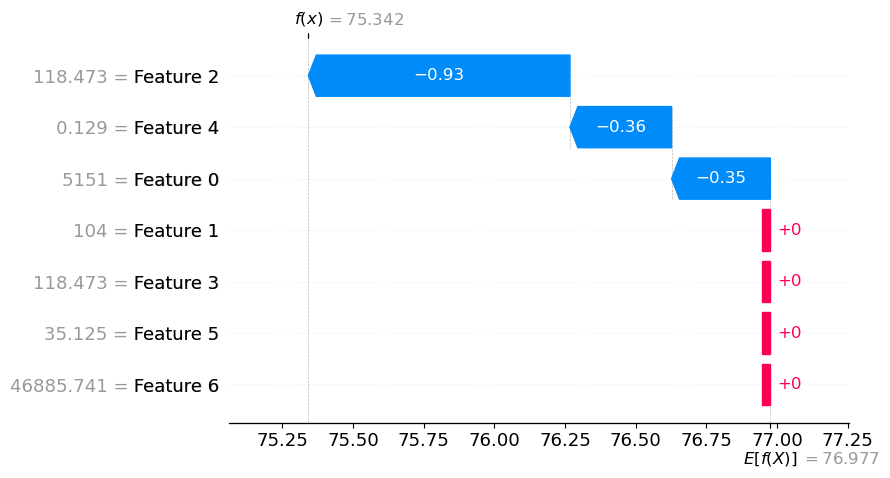

In [261]:
ip3_explainer_hgb_pg   = shap.TreeExplainer(ip3_final_hgb_pg)
ip3_shap_values_hgb_pg = ip3_explainer_hgb_pg.shap_values(X_final)

feature_names = ip3_best_features_pg["HGB"]

# Summary plot — shows feature importance + direction of effect
shap.summary_plot(ip3_shap_values_hgb_pg, X_final, feature_names=feature_names)

# Bar plot — mean absolute SHAP value per feature (cleaner for reports)
shap.summary_plot(ip3_shap_values_hgb_pg, X_final, feature_names=feature_names, plot_type="bar")

# Single prediction explanation — useful for the dashboard
shap.waterfall_plot(ip3_explainer_hgb_pg(X_final)[0])  # explains first observation

### PSV

In [ ]:
THRESHOLDS = [0.001, 0.005, 0.01, 0.03, 0.05, 0.1, 0.15, 0.199]
ip3_best_features_psv = tune_threshold("psv_global", df_ip3_eng, "IP3", THRESHOLDS, all_feature_list=all_feature_list)

[clarif] 34 features selected with Abs_r >= 0.001
[uf] 6 features selected with Abs_r >= 0.001
[pg] 245 features selected with Abs_r >= 0.001
[psv_global] 9 features selected with Abs_r >= 0.001
STAGE: PSV_GLOBAL  |  target: PSV_010 PSV - Yield [%]
Features: 9
  n=87 observations

  Model                 Train R²   LOO R²     Diff   LOO RMSE    NRMSE   LOO MAE
  --------------------------------------------------------------------------------
  OLS                     0.1762  -0.0560   0.2322    6.850pp    0.093    5.067pp
  HGB                     0.5283  -0.0596   0.5879    6.862pp    0.093    5.358pp
  RandomForest            0.3391   0.0097   0.3294    6.633pp    0.090    5.033pp
[clarif] 32 features selected with Abs_r >= 0.005
[uf] 6 features selected with Abs_r >= 0.005
[pg] 236 features selected with Abs_r >= 0.005
[psv_global] 9 features selected with Abs_r >= 0.005
STAGE: PSV_GLOBAL  |  target: PSV_010 PSV - Yield [%]
Features: 9
  n=87 observations

  Model                 Tr

In [263]:
eng_psv = ['eng4_psv_ag_x_elisa', 'eng4_psv_ag_x_volume']

for model in ip3_best_features_psv:
    ip3_best_features_psv[model] = list(dict.fromkeys(ip3_best_features_psv[model] + eng_psv))

#### Hyperparameter tune HGB & RF

In [264]:
ip3_best_hgb_psv, ip3_study_hgb_psv = tune_hgb_optuna(
    stage_name  = "psv_global",
    target      = STAGE_TARGETS["psv_global"],
    features    = ip3_best_features_psv["HGB"],
    df          = df_ip3_eng,
    n_trials    = 100,
    diff_weight = 0.5,
)


OPTUNA HGB: PSV_GLOBAL
  Best score     : 0.0129
  Best params    : {'max_iter': 86, 'max_depth': 5, 'learning_rate': 0.011245850003555177, 'min_samples_leaf': 24, 'l2_regularization': 2.26649659436775, 'max_features': 0.9612357786306782}
  Train R²       : 0.1404
  LOO R²         : 0.0554
  Diff           : 0.0850
  RMSE           : 6.4785
  NRMSE          : 0.0881
  MAE            : 4.9756


In [265]:
ip3_best_rf_psv, ip3_study_rf_psv = tune_rf_optuna(
    stage_name  = "psv_global",
    target      = STAGE_TARGETS["psv_global"],
    features    = ip3_best_features_psv["RandomForest"],
    df          = df_ip3_eng,
    n_trials    = 50,
    diff_weight = 0.5,
)


OPTUNA RF -> PSV_GLOBAL
  Best score     : -0.0335
  Best params    : {'n_estimators': 447, 'max_depth': 4, 'min_samples_leaf': 20, 'min_samples_split': 4, 'max_features': 'log2'}
  Train R²       : 0.1206
  LOO R²         : 0.0179
  Diff           : 0.1027
  RMSE           : 6.6060pp
  NRMSE          : 0.0899
  MAE            : 5.0346pp


#### STOP to check PSV

In [266]:
# Best params found by Optuna are stored in study.best_params
ip3_final_hgb_psv = HistGradientBoostingRegressor(**{**ip3_study_hgb_psv.best_params, "random_state": 42})

df_work = df_ip3_eng[ip3_best_features_psv["HGB"] + [STAGE_TARGETS["psv_global"]]].copy()
df_work = df_work[df_work[STAGE_TARGETS["psv_global"]].notna()].reset_index(drop=True)
X_final = df_work[ip3_best_features_psv["HGB"]].values
y_final = df_work[STAGE_TARGETS["psv_global"]].values

ip3_final_hgb_psv.fit(X_final, y_final)
print("Final model trained on all 88 observations ✓")

########################################################

loo    = LeaveOneOut()
y_cv   = cross_val_predict(ip3_final_hgb_psv, X_final, y_final, cv=loo)
tr     = r2_score(y_final, ip3_final_hgb_psv.predict(X_final))
loo_r2 = r2_score(y_final, y_cv)
diff   = tr - loo_r2
rmse   = np.sqrt(mean_squared_error(y_final, y_cv))
nrmse  = rmse / y_final.mean()
mae    = mean_absolute_error(y_final, y_cv)

print(f"\nTrain R²: {tr:.4f}")
print(f"LOO R²  : {loo_r2:.4f}")
print(f"Diff    : {diff:.4f}")
print(f"RMSE    : {rmse:.4f}pp")
print(f"NRMSE   : {nrmse:.4f}")
print(f"MAE     : {mae:.4f}pp")

########################################################

# Save model and feature list together so we know what columns to pass on Dashboard
joblib.dump({
    "model":    ip3_final_hgb_psv,
    "features": ip3_best_features_psv["HGB"],
    "target":   STAGE_TARGETS["psv_global"],
}, "C:/Hackathon-GSK/outputs/models/IP3_psv_model.pkl")

print("\nModel saved to IP3_psv_model.pkl ✓")

Final model trained on all 88 observations ✓

Train R²: 0.1404
LOO R²  : 0.0554
Diff    : 0.0850
RMSE    : 6.4785pp
NRMSE   : 0.0881
MAE     : 4.9756pp

Model saved to IP3_psv_model.pkl ✓


#### SHAP HGB

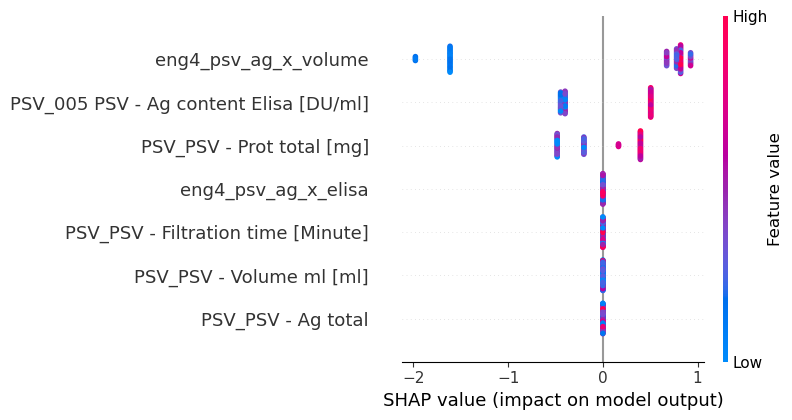

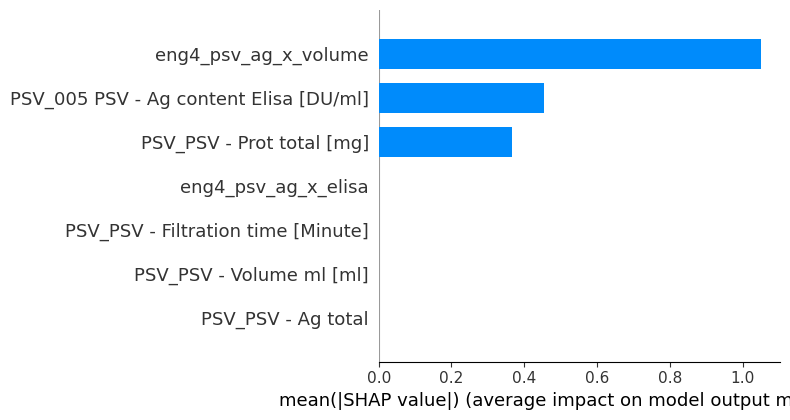

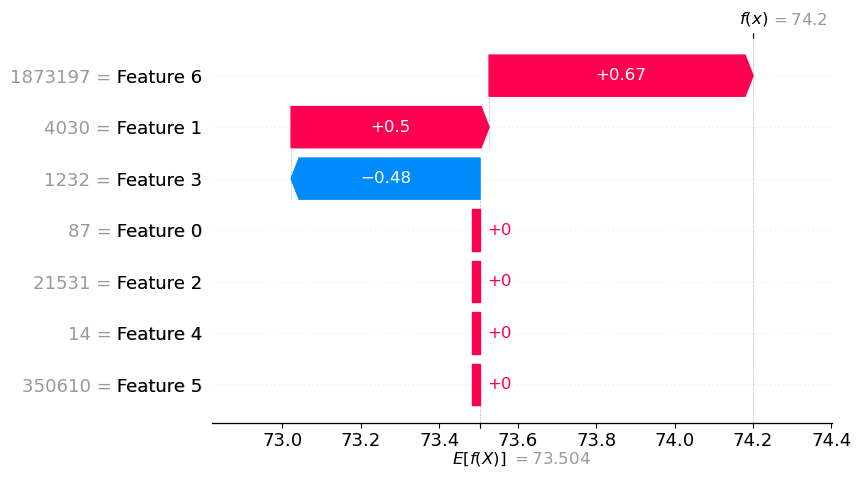

In [267]:
ip3_explainer_hgb_psv   = shap.TreeExplainer(ip3_final_hgb_psv)
ip3_shap_values_hgb_psv = ip3_explainer_hgb_psv.shap_values(X_final)

feature_names = ip3_best_features_psv["HGB"]

# Summary plot: shows feature importance + direction of effect
shap.summary_plot(ip3_shap_values_hgb_psv, X_final, feature_names=feature_names)

# Bar plot: mean absolute SHAP value per feature (cleaner for reports)
shap.summary_plot(ip3_shap_values_hgb_psv, X_final, feature_names=feature_names, plot_type="bar")

# Single prediction explanation: useful for the dashboard
shap.waterfall_plot(ip3_explainer_hgb_psv(X_final)[0])  # explains first observation

### Global

In [268]:
#Workaround, remember to change it back:
STAGE_TARGETS = {
    "global": TARGET
}
THRESHOLDS =[0.096, 0.097, 0.0981, 0.1, 0.101, 0.15, 0.199]
ip3_best_features_global = tune_threshold("global", df_ip3_eng, "IP3", THRESHOLDS, all_feature_list=all_feature_list_global)
#Changing it back:
STAGE_TARGETS = {
    "clarif":     "clarif_007 Clarif - Yield total [%]",
    "uf":         "UF_008 UF - Yield [%]",
    "pg":         "PG_009 PG - Yield [%]",
    "psv_global": "PSV_010 PSV - Yield [%]",
}

[global] 330 features selected with Abs_r >= 0.096
STAGE: GLOBAL  |  target: GY_011 PSV - Global Yield total [%]
Features: 330
  n=87 observations

  Model                 Train R²   LOO R²     Diff   LOO RMSE    NRMSE   LOO MAE
  --------------------------------------------------------------------------------
  OLS                     1.0000 -17.6792  18.6792   10.439pp    0.316    2.183pp
  HGB                     0.9419   0.4841   0.4578    1.735pp    0.052    1.339pp
  RandomForest            0.5942   0.1943   0.3998    2.168pp    0.066    1.675pp
[global] 327 features selected with Abs_r >= 0.097
STAGE: GLOBAL  |  target: GY_011 PSV - Global Yield total [%]
Features: 327
  n=87 observations

  Model                 Train R²   LOO R²     Diff   LOO RMSE    NRMSE   LOO MAE
  --------------------------------------------------------------------------------
  OLS                     1.0000 -18.5205  19.5205   10.672pp    0.323    2.200pp
  HGB                     0.9419   0.4852   0.45

In [269]:
eng_global = ['eng4_clarif_protein_x_duration', 'eng4_clarif_ag_x_duration', 'eng4_clarif_cells_x_duration', 'eng4_clarif_d0_x_d5',
           'eng4_uf_ag_x_volume', 'eng4_uf_elisa_x_volume', 'eng4_uf_ag_elisa_x_total',
           'eng4_pg_ag_x_packing_s1', 'eng4_pg_ag_x_packing_s2', 'eng4_pg_xv_x_uv_harvest', 'eng4_pg_ti_a1_x_ti_a2', 'eng4_pg_ag_x_accumulated_vol',
           'eng4_psv_ag_x_elisa', 'eng4_psv_ag_x_volume']

for model in ip3_best_features_global:
    ip3_best_features_global[model] = list(dict.fromkeys(ip3_best_features_global[model] + eng_global))

#### Hyperparameter tune HGB & RF

In [270]:
# Run best_hgb_optuna()
ip3_best_hgb_global, ip3_study_global = tune_hgb_optuna(
    stage_name  = "global",
    target      = TARGET,
    features    = ip3_best_features_global["HGB"],
    df          = df_ip3_eng,
    n_trials    = 100,
    diff_weight = 0.5,
)


OPTUNA HGB: GLOBAL
  Best score     : 0.5023
  Best params    : {'max_iter': 454, 'max_depth': 2, 'learning_rate': 0.02199355785989613, 'min_samples_leaf': 11, 'l2_regularization': 0.7887227385797915, 'max_features': 0.9792715266134752}
  Train R²       : 0.9866
  LOO R²         : 0.6637
  Diff           : 0.3228
  RMSE           : 1.4007
  NRMSE          : 0.0424
  MAE            : 1.0780


In [271]:
ip3_best_rf_global, ip3_study_rf_global = tune_rf_optuna(
    stage_name  = "global",
    target      = TARGET,
    features    = ip3_best_features_global["RandomForest"],
    df          = df_ip3_eng,
    n_trials    = 50,
    diff_weight = 0.5,
)


OPTUNA RF -> GLOBAL
  Best score     : 0.1282
  Best params    : {'n_estimators': 123, 'max_depth': 2, 'min_samples_leaf': 10, 'min_samples_split': 13, 'max_features': 0.5}
  Train R²       : 0.5522
  LOO R²         : 0.2696
  Diff           : 0.2826
  RMSE           : 2.0644pp
  NRMSE          : 0.0624
  MAE            : 1.5961pp


#### STOP to check Global Model

In [272]:
# Best params found by Optuna are stored in study.best_params
ip3_final_hgb_global = HistGradientBoostingRegressor(**ip3_study_global.best_params, random_state=42)

df_work = df_ip3_eng[ip3_best_features_global["HGB"] + [TARGET]].copy()
df_work = df_work[df_work[TARGET].notna()].reset_index(drop=True)
X_final = df_work[ip3_best_features_global["HGB"]].values
y_final = df_work[TARGET].values

ip3_final_hgb_global.fit(X_final, y_final)
print("Final model trained on all 88 observations ✓")

Final model trained on all 88 observations ✓


In [273]:
loo    = LeaveOneOut()
y_cv   = cross_val_predict(ip3_final_hgb_global, X_final, y_final, cv=loo)
tr     = r2_score(y_final, ip3_final_hgb_global.predict(X_final))
loo_r2 = r2_score(y_final, y_cv)
diff   = tr - loo_r2
rmse   = np.sqrt(mean_squared_error(y_final, y_cv))
nrmse  = rmse / y_final.mean()
mae    = mean_absolute_error(y_final, y_cv)

print(f"\nTrain R²: {tr:.4f}")
print(f"LOO R²  : {loo_r2:.4f}")
print(f"Diff    : {diff:.4f}")
print(f"RMSE    : {rmse:.4f}pp")
print(f"NRMSE   : {nrmse:.4f}")
print(f"MAE     : {mae:.4f}pp")


Train R²: 0.9866
LOO R²  : 0.6637
Diff    : 0.3228
RMSE    : 1.4007pp
NRMSE   : 0.0424
MAE     : 1.0780pp


In [274]:
# Save model and feature list together so we know what columns to pass on Dashboard
joblib.dump({
    "model":    ip3_final_hgb_global,
    "features": ip3_best_features_global["HGB"],
    "target":   TARGET,
}, "C:/Hackathon-GSK/outputs/models/IP3_hgb_global_model.pkl")

print("Model saved to IP3_hgb_global_model.pkl ✓")

Model saved to IP3_hgb_global_model.pkl ✓


#### SHAP Global Values

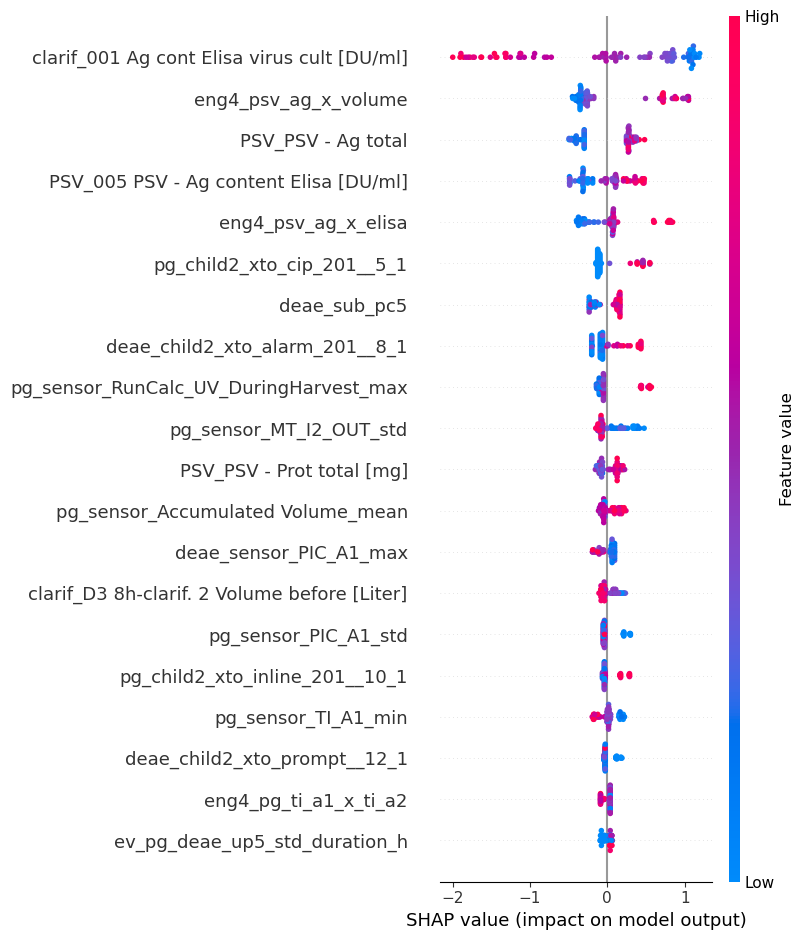

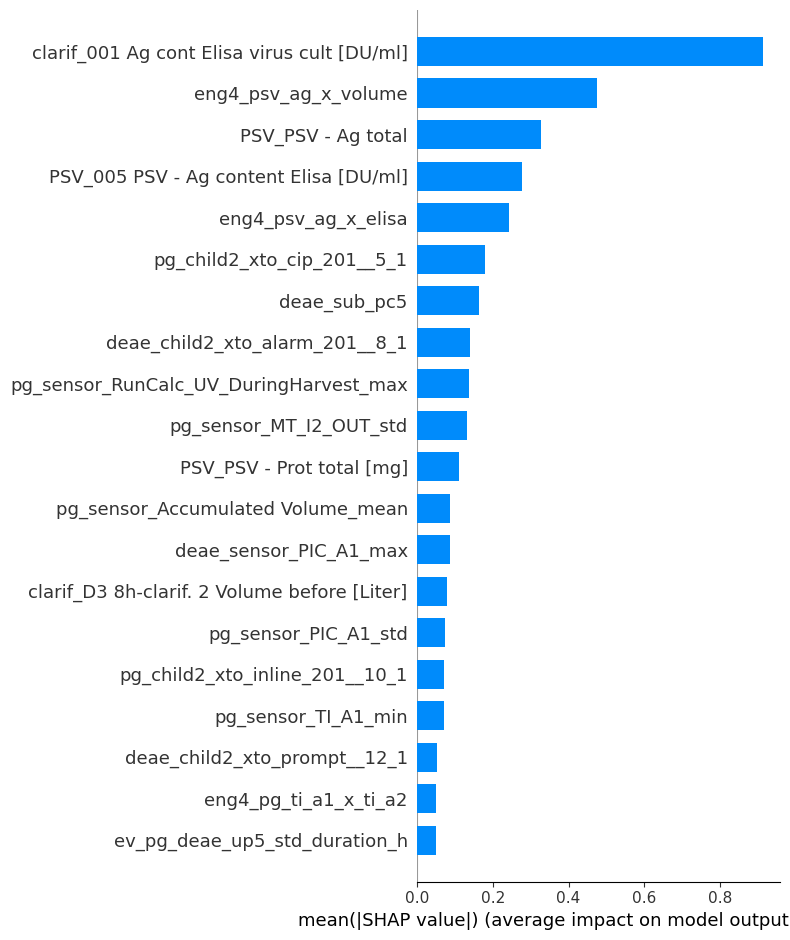

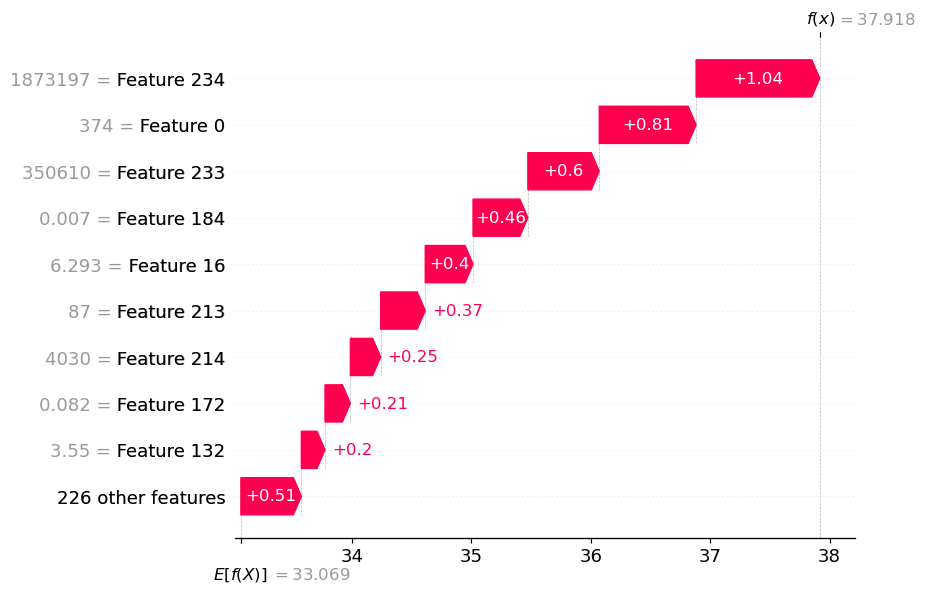

In [275]:
ip3_explainer_hgb_global   = shap.TreeExplainer(ip3_final_hgb_global)
ip3_shap_values_hgb_global = ip3_explainer_hgb_global.shap_values(X_final)

feature_names = ip3_best_features_global["HGB"]

# Summary plot: shows feature importance + direction of effect
shap.summary_plot(ip3_shap_values_hgb_global, X_final, feature_names=feature_names)

# Bar plot: mean absolute SHAP value per feature (cleaner for reports)
shap.summary_plot(ip3_shap_values_hgb_global, X_final, feature_names=feature_names, plot_type="bar")

# Single prediction explanation: useful for the dashboard
shap.waterfall_plot(ip3_explainer_hgb_global(X_final)[0])  # explains first observation

#### Export RF and OLS as well

In [276]:
# Best params found by Optuna are stored in study.best_params
ip3_final_rf_global = RandomForestRegressor(**{**ip3_study_rf_global.best_params, "random_state": 42})

df_work = df_ip3_eng[ip3_best_features_global["RandomForest"] + [TARGET]].copy()
df_work = df_work[df_work[TARGET].notna()].reset_index(drop=True)
X_final = df_work[ip3_best_features_global["RandomForest"]].values
y_final = df_work[TARGET].values

ip3_final_rf_global.fit(X_final, y_final)
print("Final model trained on all 88 observations ✓")

joblib.dump({
    "model":    ip3_final_rf_global,
    "features": ip3_best_features_global["RandomForest"],
    "target":   TARGET,
}, "C:/Hackathon-GSK/outputs/models/IP3_rf_global_model.pkl")

print("Model saved to IP3_hgb_rf_global_model.pkl ✓")

Final model trained on all 88 observations ✓
Model saved to IP3_hgb_rf_global_model.pkl ✓


In [277]:
ip3_final_ols_global = LinearRegression()

df_work = df_ip3_eng[ip3_best_features_global["OLS"] + [TARGET]].copy()
df_work = df_work[df_work[TARGET].notna()].reset_index(drop=True)
X_final = df_work[ip3_best_features_global["OLS"]].values
y_final = df_work[TARGET].values

ip3_final_ols_global.fit(X_final, y_final)
print("Final model trained on all 88 observations ✓")

joblib.dump({
    "model":    ip3_final_ols_global,
    "features": ip3_best_features_global["OLS"],
    "target":   TARGET,
}, "C:/Hackathon-GSK/outputs/models/IP3_ols_global_model.pkl")

print("Model saved to IP3_ols_global_model.pkl ✓")

Final model trained on all 88 observations ✓
Model saved to IP3_ols_global_model.pkl ✓
